In [1]:
import pandas as pd 
import numpy as np 
from glob import glob
import os
import geopandas as gpd

import csv
import json

from ast import literal_eval

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

/usr/local/lib/python3.8/dist-packages/geopandas/_compat.py:123: UserWarning: The Shapely GEOS version (3.11.2-CAPI-1.17.2) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/tmp/tmp.UD0T5wwPye/ipykernel_1156126/1202821736.py:5: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration

In [4]:
buffertracker = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/data/nonevents_ofinterest/buffertimes_for_nceievents.csv")

display(buffertracker.head(2))

print(len(buffertracker))

# Combine stats for events AND their buffers. 

stats_events = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_wQPE_rerun.csv") #HERE!! stats_wQPE_rerun.csv or stats.csv

stats_buffer = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/models/stats_events_modelpred/stats_bufferwQPE_rerun.csv") # HERE!! note that this has a lot more data in it than the buffer tracker (what we actually needed to run). Why? bc when we do operations model preds, we run it statewide -- so ALL locations / wfos (for all cams) are included in the stats here. We will want to inner join with the tracker, buffertracker to grab just those that we needed.  
# stats_bufferwQPE_rerun
# stats_buffer

stats_buffer = stats_buffer.drop(columns = ['id_event','id_ep']) # these were just set to the datetimes, meaningless at the moment
stats_buffer = stats_buffer.rename(columns = {"id_type":"type"})

# To connect the buffer data to the events data, use the buffer tracker dataframe we saved out which has the event (id_event), buffer times, location. The code for setting up that df was in /home/csutter/DRIVE-clean/weather_events/notebooks/ncei_dataset_analysis.ipynb (but the data is saved out and we can use it), but it can be merged to stats_buffer via location, which will tie the event id to buffer -- which is what we need here for plotting buffer times with the events themselcves

buffertracker = pd.read_csv("/home/csutter/DRIVE-clean/weather_events/data/nonevents_ofinterest/buffertimes_for_nceievents.csv")

stats_buffer_connect = stats_buffer.merge(buffertracker, how = "inner", left_on = ["id_loc", "id_wfo", "datetime"], right_on = ["buffer_loc", "buffer_wfo", "buffer_datetime"])

# adjust cols

# rename cols to match stats_events so that concat of dfs is clean
# stats_buffer_use = stats_buffer_connect.rename(columns = {"buffer_for_event_id":"id_event","buffer_wfo":"id_wfo","buffer_loc":"id_loc"})

stats_buffer_connect['id_type'] = stats_buffer_connect['type'] + '_' + stats_buffer_connect['buffer_type']
stats_buffer_connect['id_ep'] = 999
stats_buffer_connect['id_event'] = stats_buffer_connect['buffer_for_event_id'] #THIS is where id_event is connected to match that of the NCEI events. See larger "To connect" note above. 
stats_buffer_connect = stats_buffer_connect.drop(columns = ['type', 'buffer_wfo', 'buffer_loc', 'Unnamed: 0', 'buffer_type', 'buffer_datetime','buffer_for_event_id'])

print(len(stats_events)) # stats for ncei events, split by date and location
print(len(stats_buffer)) # buffers for datetimes needed for ncei events PLUS ran statewide -- so much longer than the actual amount of datetimes needed
print(len(buffertracker)) # buffer times needed (tracker)
print(len(stats_buffer_connect)) # after merging, should be similar to above, although some model preds may be missing if there were no images for a buffer datetime


stats = pd.concat([stats_events, stats_buffer_connect])

# to read in the model counts col as dictionaries
stats["model_counts"] = stats["model_counts"].apply(literal_eval)

print("all rows (not cleaned)")
print(len(stats))

stats.head(4)

stats.columns

print(np.unique(stats["id_type"]))

stats_wpreds = stats[stats["model_counts"]!={}].reset_index()

print("rows WITH camera preds")
print(len(stats_wpreds))

# Add columns to dataframe for easy analysis and plotting

catslist = ["snow_severe", "snow", "wet", "dry", "poor_viz"]

#### Add columns for each cat (counts)
def row_amt_bycat(row):
    rowdict = row["model_counts"]
    totalcams = np.sum(rowdict.values)
    cat_counts = []
    for cat in catslist:
        if cat in rowdict.keys():
            catval = rowdict[cat]
        else:
            catval = 0
        cat_counts.append(catval)
    return cat_counts

stats_wpreds["cat_counts"] = stats_wpreds.apply(row_amt_bycat, axis=1)

# Rather than having the one col in df w/ the list of cat counts, like [52, 3, 0, 1, 1], split those into 5 separate cols
new_cols_df = pd.DataFrame(stats_wpreds['cat_counts'].tolist(), columns=catslist)

stats_wpreds_catcols = pd.concat([stats_wpreds, new_cols_df], axis=1)

# Add total cams so that we can get percentages, proportion
totalcams = stats_wpreds_catcols[catslist].sum(axis=1).tolist()

stats_wpreds_catcols["totalcams"] = totalcams

#### Add columns for each cat (percentages)
def row_amt_bycat(row):
    cat_proportions = []
    for cat in catslist:
        perc = np.round(row[cat]/row["totalcams"],4)
        cat_proportions.append(perc)
    return cat_proportions

stats_wpreds_catcols["cat_percents"] = stats_wpreds_catcols.apply(row_amt_bycat, axis=1)

# Rather than having the one col in df w/ the list of cat counts, like [52, 3, 0, 1, 1], split those into 5 separate cols

catslist_perc = [f"{c}_perc" for c in catslist] # FOR PLOTTING
new_cols_df2 = pd.DataFrame(stats_wpreds_catcols['cat_percents'].tolist(), columns=catslist_perc)

stats_wpreds_allinfo = pd.concat([stats_wpreds_catcols, new_cols_df2], axis=1)

# CLEAN UP DATA (dups, etc)
print("drop dups")
print(len(stats_wpreds_allinfo))
stats_wpreds_allinfo = stats_wpreds_allinfo.drop(columns = ["index", "model_counts","cat_percents", "cat_counts"]) # cols that are dict and list b/c they're weird for pd operations and we've already added the data by cols that we need
stats_wpreds_allinfo = stats_wpreds_allinfo.drop_duplicates(ignore_index=True)
print(len(stats_wpreds_allinfo))

# sort df by time

stats_wpreds_allinfo = stats_wpreds_allinfo.sort_values("datetime")

stats_wpreds_allinfo['timestep'] = range(1, len(stats_wpreds_allinfo)+1) # we sorted by timestamp but it's a string, so add col of integers representing time steps through duration of event


# HERE!! Set what you want to call this df to be unique if going to run this code again for another version
# data_anyqpe = stats_wpreds_allinfo 
data_wqpe = stats_wpreds_allinfo

,Unnamed: 0,buffer_for_event_id,buffer_type,buffer_datetime,buffer_loc,buffer_wfo
0,0,996866,before,20220129_1100,SOUTHWEST SUFFOLK,OKX
1,1,996866,before,20220129_1115,SOUTHWEST SUFFOLK,OKX


3768
36404
21935
3768
1278
all rows (not cleaned)
37682
['Blizzard' 'Heavy Rain' 'Heavy Snow' 'Lake-Effect Snow' 'Winter Storm'
 'Winter Weather' 'buffer_after' 'buffer_before']
rows WITH camera preds
37682
drop dups
37682
28467


# Organize data - QPE vs non-QPE

In [5]:
# rename cols of the wQPE vs anyQPE so that the join has distinct meaningul col names

renamcols = ['snow_severe', 'snow', 'wet', 'dry',
       'poor_viz', 'totalcams', 'snow_severe_perc',
       'snow_perc', 'wet_perc', 'dry_perc', 'poor_viz_perc', 'timestep']

# wQPE renaming
renamemapping_wQPE = {col: f"{col}_wQPE" for col in renamcols}
data_wqpe = data_wqpe.rename(columns=renamemapping_wQPE)

# anyQPE renaming
renamemapping_anyQPE = {col: f"{col}_anyQPE" for col in renamcols}
data_anyqpe = data_anyqpe.rename(columns=renamemapping_anyQPE)

data_anyqpe.head(3)

# outer join the dfs to get each row and the relevant stats for QPE vs non QPE
# need to outer join bc there are events and times where there was NO qpe, and we need to know that so we can say 0 cams for that case 

mergeon = ['id_event', 'id_ep', 'id_type', 'id_loc', 'id_wfo', 'datetime']

data = data_anyqpe.merge(data_wqpe, how = "outer", on = mergeon)



# Add columns regarding the % of cams that had QPE (>0.1)
data["prop_cams_QPE"] = data["totalcams_wQPE"]/data["totalcams_anyQPE"]

print(len(data)) # should be the lenth of the data_anyqpe since that has more / all cases!
print(data.columns)
display(data.head(2))

44896
Index(['id_event', 'id_ep', 'id_type', 'id_loc', 'id_wfo', 'datetime',
       'snow_severe_anyQPE', 'snow_anyQPE', 'wet_anyQPE', 'dry_anyQPE',
       'poor_viz_anyQPE', 'totalcams_anyQPE', 'snow_severe_perc_anyQPE',
       'snow_perc_anyQPE', 'wet_perc_anyQPE', 'dry_perc_anyQPE',
       'poor_viz_perc_anyQPE', 'timestep_anyQPE', 'snow_severe_wQPE',
       'snow_wQPE', 'wet_wQPE', 'dry_wQPE', 'poor_viz_wQPE', 'totalcams_wQPE',
       'snow_severe_perc_wQPE', 'snow_perc_wQPE', 'wet_perc_wQPE',
       'dry_perc_wQPE', 'poor_viz_perc_wQPE', 'timestep_wQPE',
       'prop_cams_QPE'],
      dtype='object')


,id_event,id_ep,id_type,id_loc,id_wfo,datetime,snow_severe_anyQPE,snow_anyQPE,wet_anyQPE,dry_anyQPE,...,dry_wQPE,poor_viz_wQPE,totalcams_wQPE,snow_severe_perc_wQPE,snow_perc_wQPE,wet_perc_wQPE,dry_perc_wQPE,poor_viz_perc_wQPE,timestep_wQPE,prop_cams_QPE
0,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_1100,50,0,0,0,...,0.0,9.0,59.0,0.8475,0.0000,0.0,0.0,0.1525,1.0,1.0
1,996910,999,buffer_before,NORTHWEST SUFFOLK,OKX,20220129_1100,52,1,0,0,...,0.0,3.0,56.0,0.9286,0.0179,0.0,0.0,0.0536,2.0,1.0


# Bar plots with % of locations with QPE

In [88]:
print(np.unique(data['id_type']))

['Blizzard' 'Heavy Rain' 'Heavy Snow' 'Lake-Effect Snow' 'Winter Storm'
 'Winter Weather' 'buffer_after' 'buffer_before']


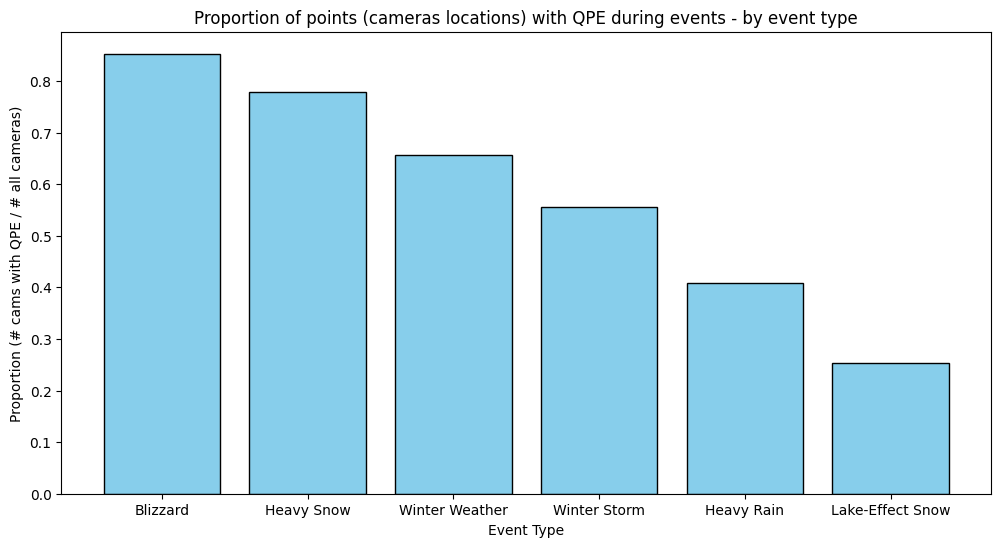

In [6]:
import matplotlib.pyplot as plt

# Subset to not use buffers; just show by event type first

dfuse = data[data['id_type'].isin(['Blizzard', 'Heavy Rain', 'Heavy Snow', 'Lake-Effect Snow', 'Winter Storm','Winter Weather'])]

def make_qpe_plot1(dfforplot, plotsubtitle, order_xpts = []):

    """
    order_xpts if an empty list, it will plot x's in a order that decreases in y valu
    """

    # Increase figure size (Width, Height)
    plt.figure(figsize=(12, 6))

    # 1. Group by id_type and sum both columns
    grouped = dfforplot.groupby('id_type')[['totalcams_anyQPE', 'totalcams_wQPE']].sum()

    # 2. Calculate the proportion
    grouped['proportion'] = grouped['totalcams_wQPE'] /grouped['totalcams_anyQPE'] 

    # 3. Sort for a cleaner visual
    if order_xpts == []:
        grouped = grouped.sort_values('proportion', ascending=False)
    else: # Force x-axis to follow exact list order 
        grouped = grouped.reindex(order_xpts)

    # 4. Plot
    plt.bar(grouped.index, grouped['proportion'], color='skyblue', edgecolor='black')
    plt.xlabel('Event Type')
    plt.ylabel('Proportion (# cams with QPE / # all cameras)')
    plt.title(f'Proportion of points (cameras locations) with QPE during events - {plotsubtitle}')
    plt.savefig('qpe_proportion.png')

make_qpe_plot1(dfuse, "by event type")

In [16]:
# Spot check a few ^ above to make sure we fully cleaned / have an understanding of the data structure


hs = data[data['id_type']=="Heavy Snow"]
print(len(hs))
print(hs['totalcams_wQPE'].sum() / hs['totalcams_anyQPE'].sum()) # if just sum cols (which uses python sum function) it will error with nans. However, by default when we use pandas operation (.sum()), it treats nans as 0s whcih is what we want

hs = data[data['id_type']=="Blizzard"]
print(len(hs))
print(hs['totalcams_wQPE'].sum() / hs['totalcams_anyQPE'].sum()) # if just sum cols (which uses python sum function) it will error with nans. However, by default when we use pandas operation (.sum()), it treats nans as 0s whcih is what we want 

hs = data[data['id_type']=="Lake-Effect Snow"]
print(len(hs))
print(hs['totalcams_wQPE'].sum() / hs['totalcams_anyQPE'].sum()) # if just sum cols (which uses python sum function) it will error with nans. However, by default when we use pandas operation (.sum()), it treats nans as 0s whcih is what we want 

4635
0.7790148324482695
1541
0.8529382219989955
12982
0.2535342653474828


In [117]:
stats_wpreds_allinfo

,id_event,id_ep,id_type,id_loc,id_wfo,datetime,snow_severe,snow,wet,dry,poor_viz,totalcams,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
26310,996910,999,buffer_before,NORTHWEST SUFFOLK,OKX,20220129_1100,52,1,0,0,3,56,0.9286,0.0179,0.0000,0.0000,0.0536,1
26311,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_1100,50,0,0,0,9,59,0.8475,0.0000,0.0000,0.0000,0.1525,2
26322,996910,999,buffer_before,NORTHWEST SUFFOLK,OKX,20220129_1115,53,1,0,0,2,56,0.9464,0.0179,0.0000,0.0000,0.0357,3
26323,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_1115,49,0,0,0,10,59,0.8305,0.0000,0.0000,0.0000,0.1695,4
26317,996910,999,buffer_before,NORTHWEST SUFFOLK,OKX,20220129_1145,55,0,0,0,1,56,0.9821,0.0000,0.0000,0.0000,0.0179,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1229,1274158,204379,Heavy Rain,JEFFERSON,BUF,20250622_0615,0,0,0,5,0,5,0.0000,0.0000,0.0000,1.0000,0.0000,27504
26446,1274158,999,buffer_after,JEFFERSON,BUF,20250622_0700,0,0,4,10,0,14,0.0000,0.0000,0.2857,0.7143,0.0000,27505
26447,1274158,999,buffer_after,JEFFERSON,BUF,20250622_0715,0,0,2,10,0,12,0.0000,0.0000,0.1667,0.8333,0.0000,27506
26445,1274158,999,buffer_after,JEFFERSON,BUF,20250622_0730,0,0,4,8,0,12,0.0000,0.0000,0.3333,0.6667,0.0000,27507


,id_type,id_event
0,Blizzard,"[996910, 996866, 996910, 996866, 996910, 99686..."
1,Heavy Rain,"[1193087, 1193087, 1193087, 1193087, 1193087, ..."
2,Heavy Snow,"[1151591, 1151590, 1151587, 1151589, 1151590, ..."
3,Lake-Effect Snow,"[1159185, 1159185, 1159185, 1159185, 1159185, ..."
4,Winter Storm,"[1146894, 1146894, 1146894, 1146894, 1146894, ..."
5,Winter Weather,"[1152943, 1152943, 1152943, 1152943, 1151677, ..."


Blizzard
[996910, 996866, 996910, 996866]
Heavy Rain
[1193087, 1193087, 1193087, 1193087]
Heavy Snow
[1151591, 1151590, 1151587, 1151589]
Lake-Effect Snow
[1159185, 1159185, 1159185, 1159185]
Winter Storm
[1146894, 1146894, 1146894, 1146894]
Winter Weather
[1152943, 1152943, 1152943, 1152943]


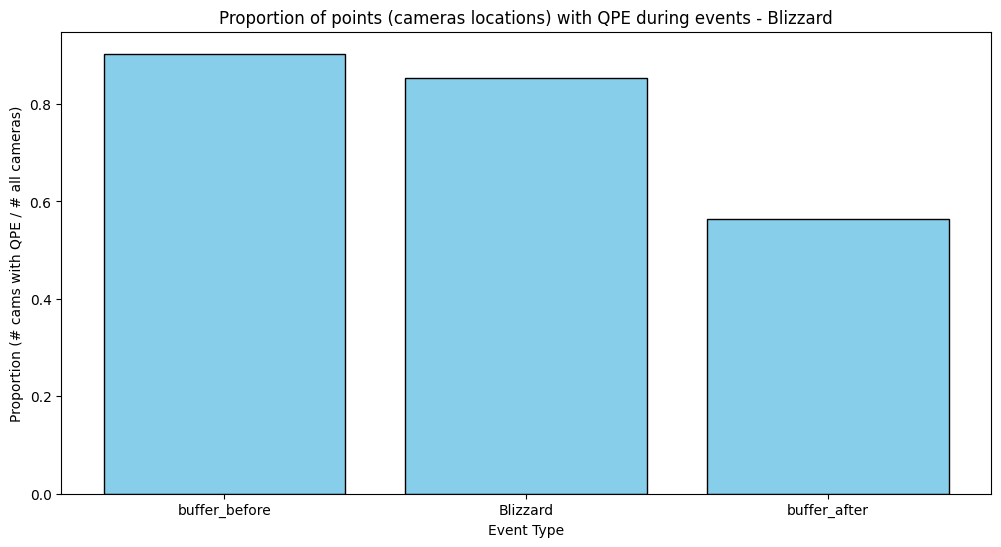

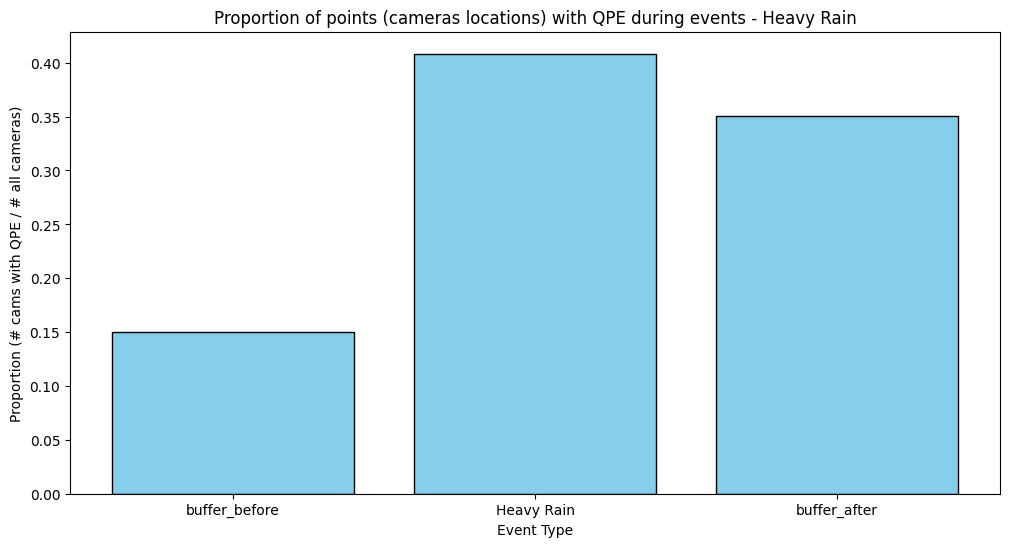

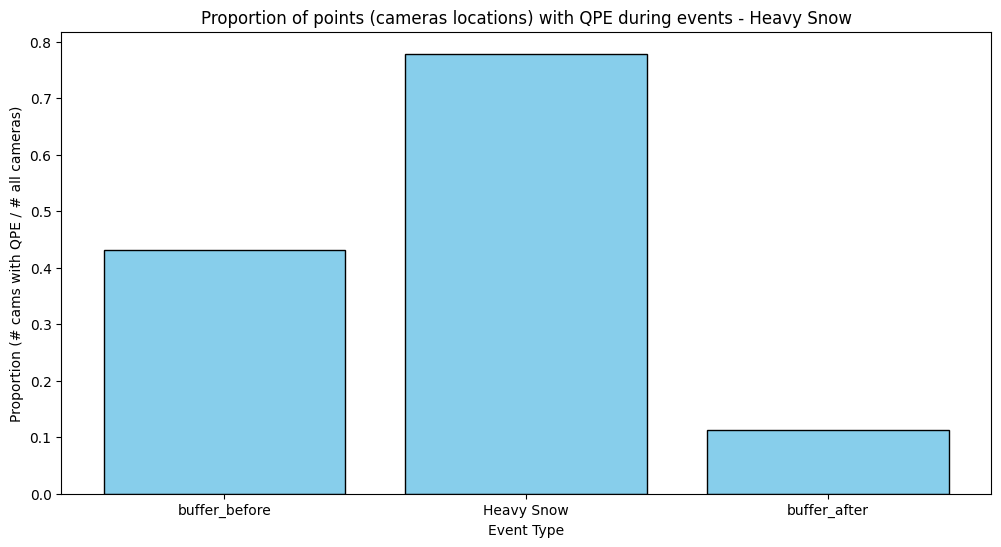

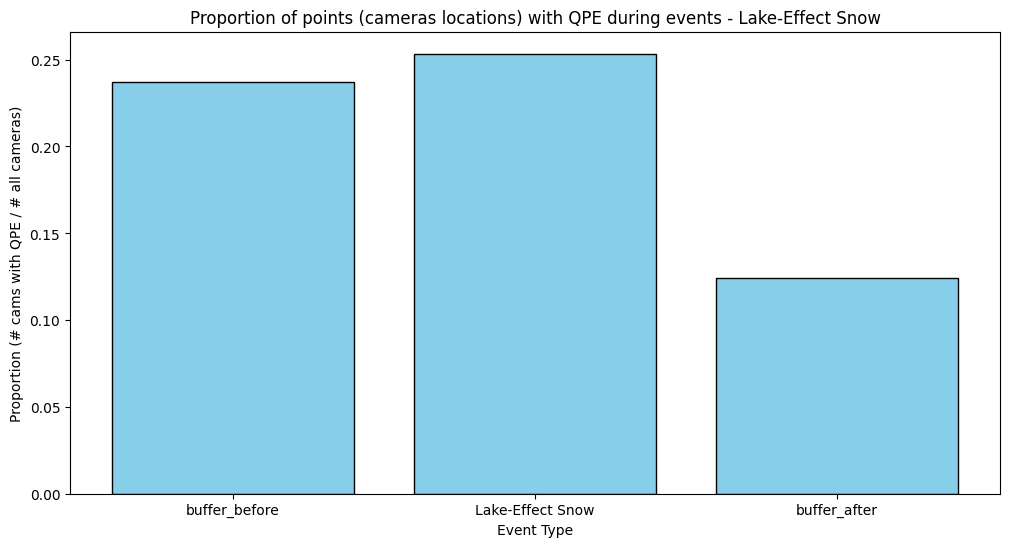

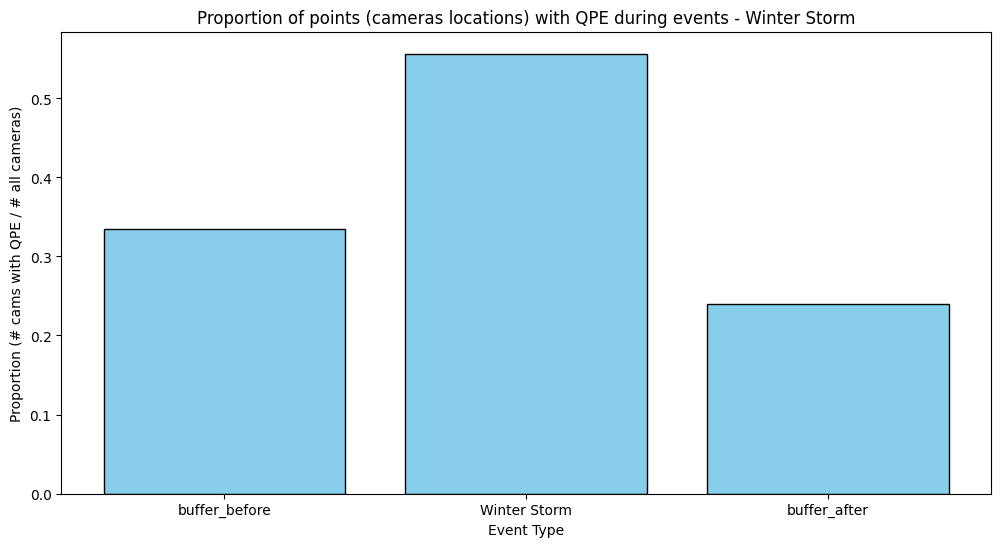

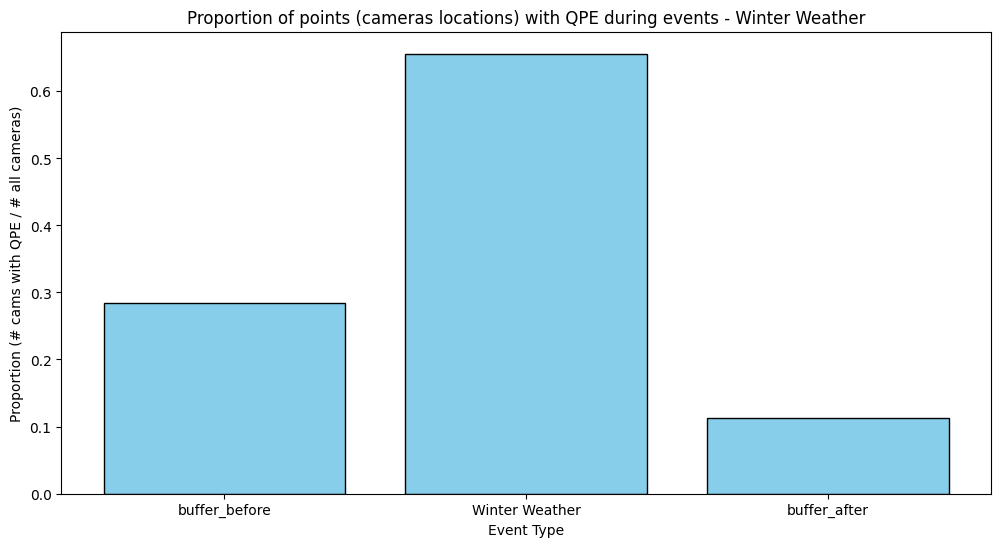

In [9]:
# For plot it for each event type

# grab event ids associated with each main weather type. Note that we already tied event_id for the buffers to their respective events when we read in the data. But since id_type for buffer times are labeled like "buffer_before", it doesn't say the event like "Heavy Snow", so for each event type like Heavy snow, we need to collect the list of id_event

dfusing = data

eventtype_associated_ids = dfusing[((dfusing["id_type"]!="buffer_before")&(dfusing["id_type"]!="buffer_after"))]
eventtype_associated_ids = eventtype_associated_ids.groupby('id_type')['id_event'].agg(list).reset_index()

display(eventtype_associated_ids)


for i in range(0, len (eventtype_associated_ids)):
    ev_type = eventtype_associated_ids["id_type"][i]
    print(ev_type)
    ev_ids_list = eventtype_associated_ids["id_event"][i]
    print(ev_ids_list[0:4])
    subsetevents = dfusing[dfusing["id_event"].isin(ev_ids_list)].reset_index()
    # display(subsetevents.head(3))
    # order = ["buffer_before",type, "buffer_after"]
    order = ['buffer_before', ev_type, 'buffer_after']
    make_qpe_plot1(subsetevents, ev_type, order)


# Just heavy rain needs investigation here. The others generally make sense. 

# Same plots as above (showing % of cams with QPE), but for case studies, zoomed into time series

In [19]:
de = data[data["id_event"] == 996866] #data.head(13)
de.head(14)

,id_event,id_ep,id_type,id_loc,id_wfo,datetime,snow_severe_anyQPE,snow_anyQPE,wet_anyQPE,dry_anyQPE,...,dry_wQPE,poor_viz_wQPE,totalcams_wQPE,snow_severe_perc_wQPE,snow_perc_wQPE,wet_perc_wQPE,dry_perc_wQPE,poor_viz_perc_wQPE,timestep_wQPE,prop_cams_QPE
0,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_1100,50,0,0,0,...,0.0,9.0,59.0,0.8475,0.0000,0.0,0.0,0.1525,1.0,1.0
2,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_1115,49,0,0,0,...,0.0,10.0,59.0,0.8305,0.0000,0.0,0.0,0.1695,4.0,1.0
4,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_1130,51,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_1145,54,1,0,0,...,0.0,4.0,59.0,0.9153,0.0169,0.0,0.0,0.0678,6.0,1.0
9,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1200,54,0,0,0,...,0.0,5.0,59.0,0.9153,0.0000,0.0,0.0,0.0847,7.0,1.0
11,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1205,56,0,0,0,...,0.0,3.0,59.0,0.9492,0.0000,0.0,0.0,0.0508,10.0,1.0
13,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1210,54,1,0,0,...,0.0,4.0,59.0,0.9153,0.0169,0.0,0.0,0.0678,12.0,1.0
14,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1215,53,2,0,0,...,0.0,4.0,59.0,0.8983,0.0339,0.0,0.0,0.0678,14.0,1.0
17,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1220,54,1,0,0,...,0.0,4.0,59.0,0.9153,0.0169,0.0,0.0,0.0678,15.0,1.0
18,996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1225,55,1,0,0,...,0.0,3.0,59.0,0.9322,0.0169,0.0,0.0,0.0508,18.0,1.0


In [14]:
de.columns

Index(['id_event', 'id_ep', 'id_type', 'id_loc', 'id_wfo', 'datetime',
       'snow_severe_anyQPE', 'snow_anyQPE', 'wet_anyQPE', 'dry_anyQPE',
       'poor_viz_anyQPE', 'totalcams_anyQPE', 'snow_severe_perc_anyQPE',
       'snow_perc_anyQPE', 'wet_perc_anyQPE', 'dry_perc_anyQPE',
       'poor_viz_perc_anyQPE', 'timestep_anyQPE', 'snow_severe_wQPE',
       'snow_wQPE', 'wet_wQPE', 'dry_wQPE', 'poor_viz_wQPE', 'totalcams_wQPE',
       'snow_severe_perc_wQPE', 'snow_perc_wQPE', 'wet_perc_wQPE',
       'dry_perc_wQPE', 'poor_viz_perc_wQPE', 'timestep_wQPE', 'prop_cams_QPE',
       'timestep'],
      dtype='object')

In [ ]:
# see 20220129_1210 and 20220129_1205 (<- nan). I think that just didnt run in agg stats code (UA servers shut down). I checked that the QPE cam preds DID actually exist and for both files and had same # of cams in them, so nothing wrong w how im pulling the QPE data I think. 


# in backfill file: 996866,165058,Blizzard,SOUTHWEST SUFFOLK,OKX,20220129_1205,"{""poor_viz"": 3, ""snow_severe"": 56}"


In [16]:
def make_qpe_timeseries(dfforplot, plotsubtitle):
    # 1. Ensure the data is sorted by time (important for line plots!)
    # Replace 'timestep' with your actual time column name if different
    dfforplot = dfforplot.sort_values('timestep')

    # 2. Create the figure
    plt.figure(figsize=(14, 6))

    # 3. Plot the line and the individual points
    plt.plot(dfforplot['timestep'], dfforplot['prop_cams_QPE'], 
             marker='o', linestyle='-', color='navy', markersize=4)

    # 4. Formatting
    plt.title(f'Time Series - Proportion of Cams w/ QPE - {plotsubtitle}')
    plt.ylabel('% of Cameras with QPE')
    plt.xlabel('Time Step')
    
    # Add a grid to help track the % values
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Optional: Rotate x-labels if they are timestamps
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

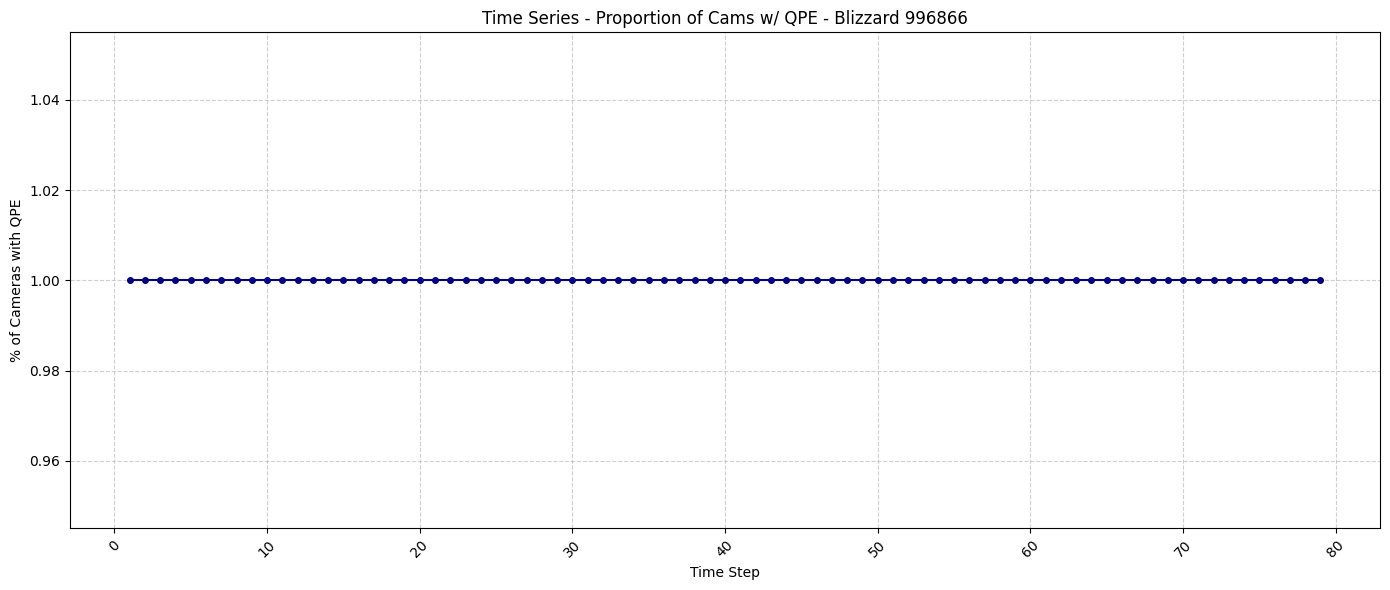

In [19]:
de = data[data["id_event"] == 996866] #data.head(13)

de = de[~de["id_type"].isin(["buffer_before","buffer_after"])]
de = de.sort_values("datetime")

de['timestep'] = range(1, len(de)+1)


de['timestep'] = range(1, len(de)+1)

de.head(3)

make_qpe_timeseries(dfforplot = de, plotsubtitle = "Blizzard 996866")

In [8]:
plot7()

NameError: name 'plot7' is not defined

In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming 'df' is your processed dataframe
# df = pd.read_csv("your_data.csv")

def plot_7(): # NOTE GLOBAL VAR OF DF, "de"
    cols_to_plot = [
        'snow_severe_anyQPE', 
        'snow_anyQPE', 
        'wet_anyQPE', 
        'dry_anyQPE', 
        'poor_viz_anyQPE'
    ]
    colors = ['#1f77b4', '#17becf', '#2ca02c', '#ff7f0e', '#d62728']

    # Initialize the figure with 7 subplots
    # Individual (1-5), Summary (6), Proportion (7)
    fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(14, 26), sharex=True, 
                            gridspec_kw={'height_ratios': [1, 1, 1, 1, 1, 2, 1.5]})

    fig.suptitle('Weather Event Metrics & Camera Coverage', fontsize=20, y=1.01)

    # Plots 1-5: Individual metrics
    for i, col in enumerate(cols_to_plot):
        axes[i].plot(de['timestep'], de[col], color=colors[i], linewidth=2, label=col)
        axes[i].set_ylabel('Count', fontsize=10)
        axes[i].set_title(f'Individual: {col}', fontsize=12, loc='left')
        axes[i].grid(True, linestyle='--', alpha=0.5)

    # Plot 6: Combined metrics (Summary)
    for i, col in enumerate(cols_to_plot):
        axes[5].plot(de['timestep'], de[col], color=colors[i], linewidth=2.5, label=col, alpha=0.8)

    axes[5].set_title('Summary: All Categories Combined', fontsize=14, fontweight='bold', loc='left')
    axes[5].set_ylabel('Total Count', fontsize=12)
    axes[5].grid(True, linestyle='-', alpha=0.3)

    # Plot 7: Proportion of Cameras with QPE (New Quantity)
    axes[6].plot(de['timestep'], de['prop_cams_QPE'], color='black', linewidth=2, linestyle='-', label='Prop Cams QPE')
    axes[6].set_title('Camera Coverage: prop_cams_QPE', fontsize=14, fontweight='bold', loc='left')
    axes[6].set_ylabel('Proportion (0-1)', fontsize=12)
    axes[6].set_ylim(0, 1.1) # Assuming it's a 0-1 proportion
    axes[6].grid(True, linestyle=':', color='gray', alpha=0.7)
    axes[6].fill_between(de['timestep'], de['prop_cams_QPE'], color='gray', alpha=0.1) # Shading for visual distinction

    # Shared X-axis label
    plt.xlabel('Timestep', fontsize=14)

    # Global Legend
    handles, labels = axes[5].get_legend_handles_labels()
    # Adding the black line for the 7th plot to the legend
    h7, l7 = axes[6].get_legend_handles_labels()
    fig.legend(handles + h7, labels + l7, loc='upper right', bbox_to_anchor=(1.2, 0.95), 
            title="Metrics & Coverage", title_fontsize='13', fontsize='12', frameon=True)

    plt.tight_layout()



def plot_7_wqpe(): # NOTE GLOBAL VAR OF DF, "de"
    cols_to_plot = [
        'snow_severe_wQPE', 
        'snow_wQPE', 
        'wet_wQPE', 
        'dry_wQPE', 
        'poor_viz_wQPE'
    ]
    colors = ['#1f77b4', '#17becf', '#2ca02c', '#ff7f0e', '#d62728']

    # Initialize the figure with 7 subplots
    # Individual (1-5), Summary (6), Proportion (7)
    fig, axes = plt.subplots(nrows=7, ncols=1, figsize=(14, 26), sharex=True, 
                            gridspec_kw={'height_ratios': [1, 1, 1, 1, 1, 2, 1.5]})

    fig.suptitle('Weather Event Metrics & Camera Coverage', fontsize=20, y=1.01)

    # Plots 1-5: Individual metrics
    for i, col in enumerate(cols_to_plot):
        axes[i].plot(de['timestep'], de[col], color=colors[i], linewidth=2, label=col)
        axes[i].set_ylabel('Count', fontsize=10)
        axes[i].set_title(f'Individual: {col}', fontsize=12, loc='left')
        axes[i].grid(True, linestyle='--', alpha=0.5)

    # Plot 6: Combined metrics (Summary)
    for i, col in enumerate(cols_to_plot):
        axes[5].plot(de['timestep'], de[col], color=colors[i], linewidth=2.5, label=col, alpha=0.8)

    axes[5].set_title('Summary: All Categories Combined', fontsize=14, fontweight='bold', loc='left')
    axes[5].set_ylabel('Total Count', fontsize=12)
    axes[5].grid(True, linestyle='-', alpha=0.3)

    # Plot 7: Proportion of Cameras with QPE (New Quantity)
    axes[6].plot(de['timestep'], de['prop_cams_QPE'], color='black', linewidth=2, linestyle='-', label='Prop Cams QPE')
    axes[6].set_title('Camera Coverage: prop_cams_QPE', fontsize=14, fontweight='bold', loc='left')
    axes[6].set_ylabel('Proportion (0-1)', fontsize=12)
    axes[6].set_ylim(0, 1.1) # Assuming it's a 0-1 proportion
    axes[6].grid(True, linestyle=':', color='gray', alpha=0.7)
    axes[6].fill_between(de['timestep'], de['prop_cams_QPE'], color='gray', alpha=0.1) # Shading for visual distinction

    # Shared X-axis label
    plt.xlabel('Timestep', fontsize=14)

    # Global Legend
    handles, labels = axes[5].get_legend_handles_labels()
    # Adding the black line for the 7th plot to the legend
    h7, l7 = axes[6].get_legend_handles_labels()
    fig.legend(handles + h7, labels + l7, loc='upper right', bbox_to_anchor=(1.2, 0.95), 
            title="Metrics & Coverage", title_fontsize='13', fontsize='12', frameon=True)

    plt.tight_layout()



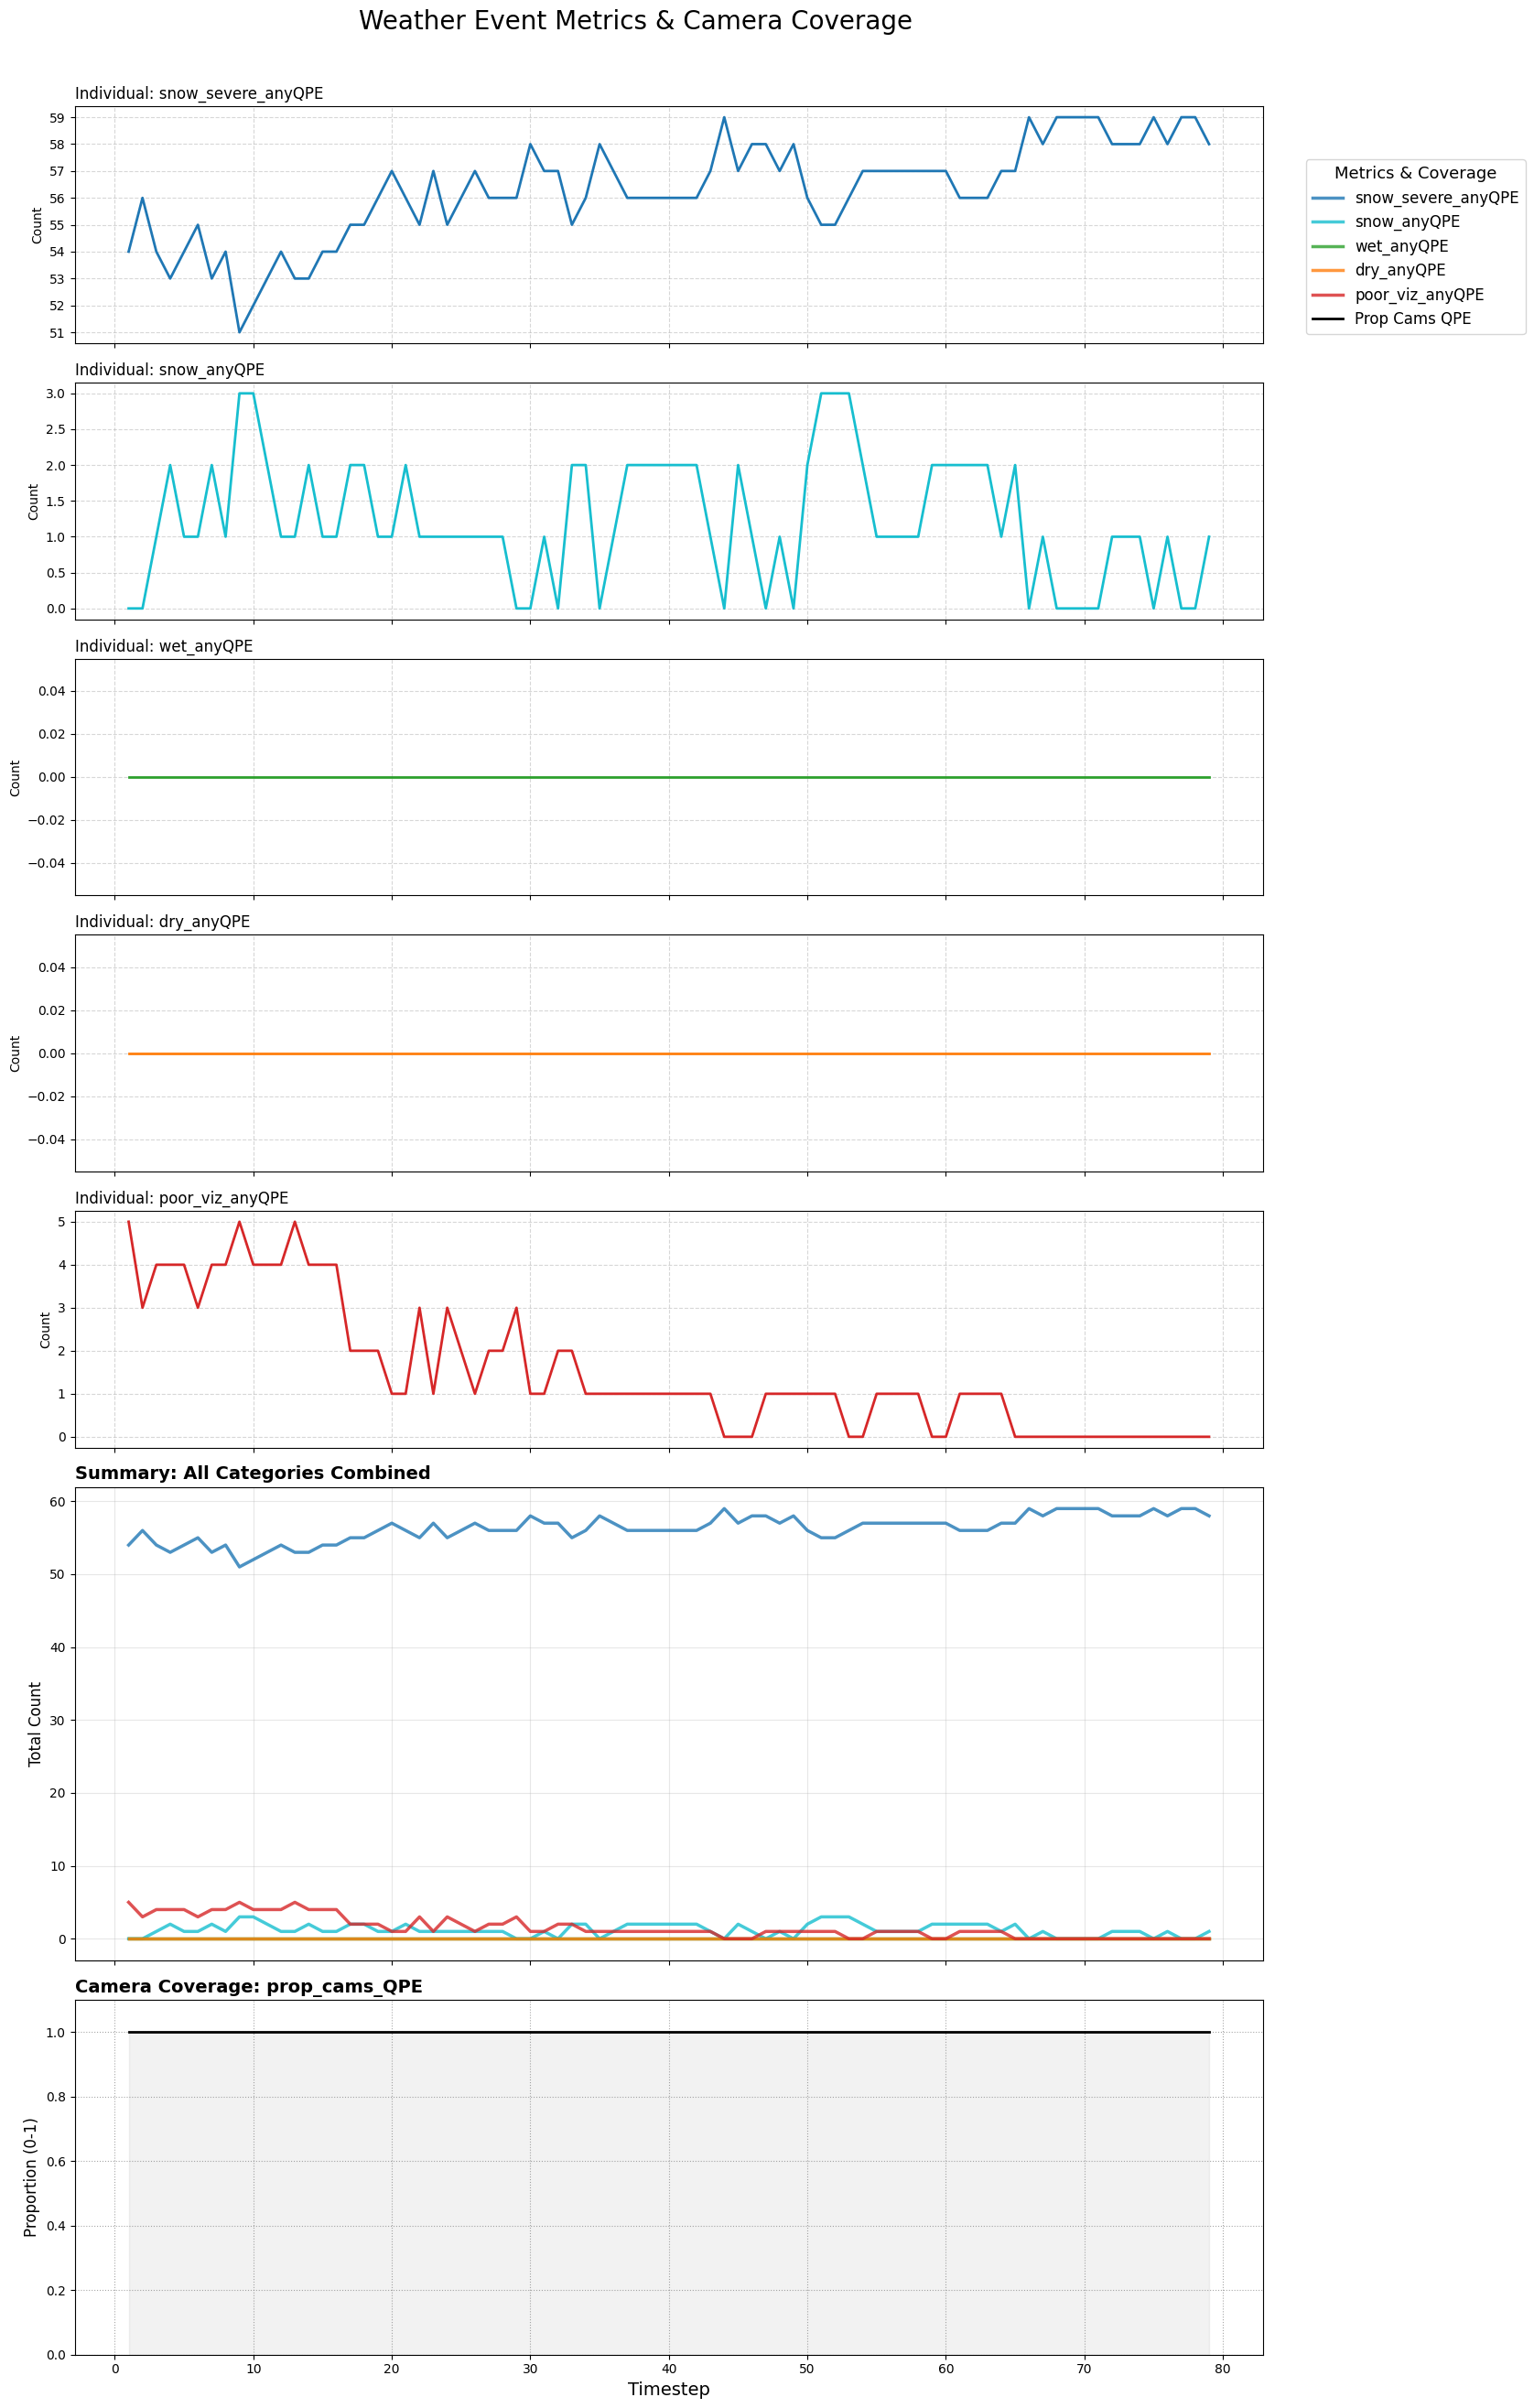

In [23]:
plot_7()

number of cams:
[61]
['Lake-Effect Snow']


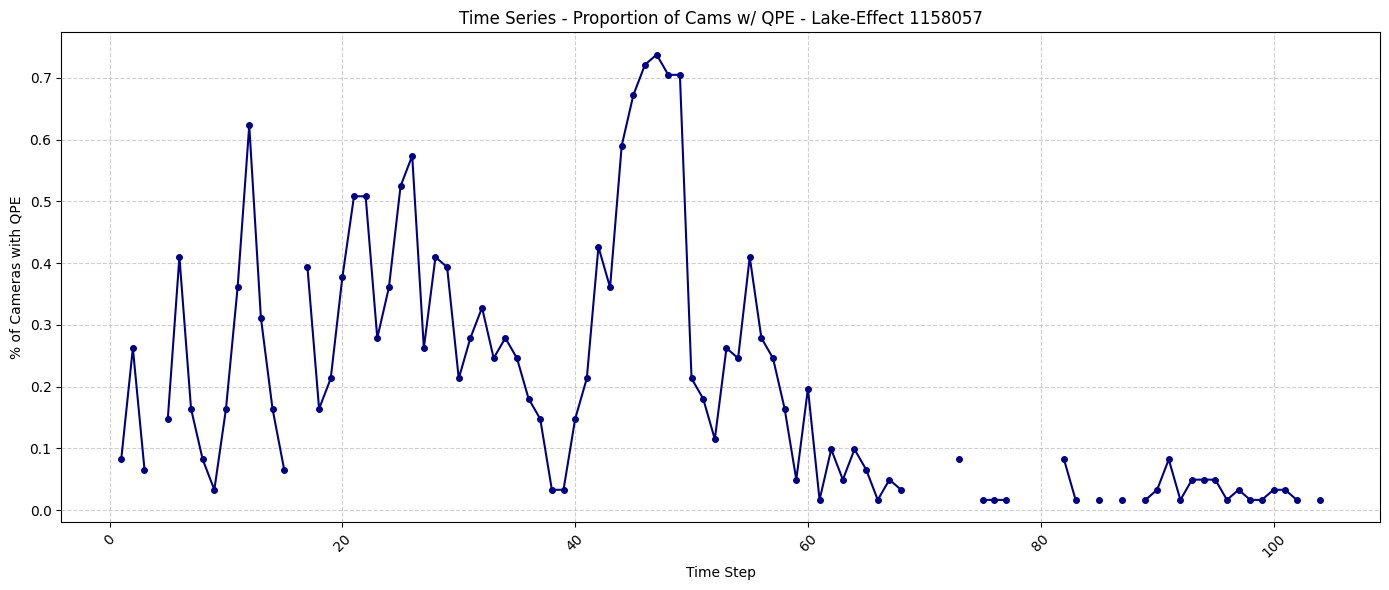

In [24]:
de = data[data["id_event"] == 1158057] #data.head(13)
de = de[~de["id_type"].isin(["buffer_before","buffer_after"])]
de = de.sort_values("datetime")

de['timestep'] = range(1, len(de)+1)

print("number of cams:")
print(np.unique(de["totalcams_anyQPE"]))

print(np.unique(de["id_type"]))

de.head(3)

make_qpe_timeseries(dfforplot = de, plotsubtitle = "Lake-Effect 1158057")

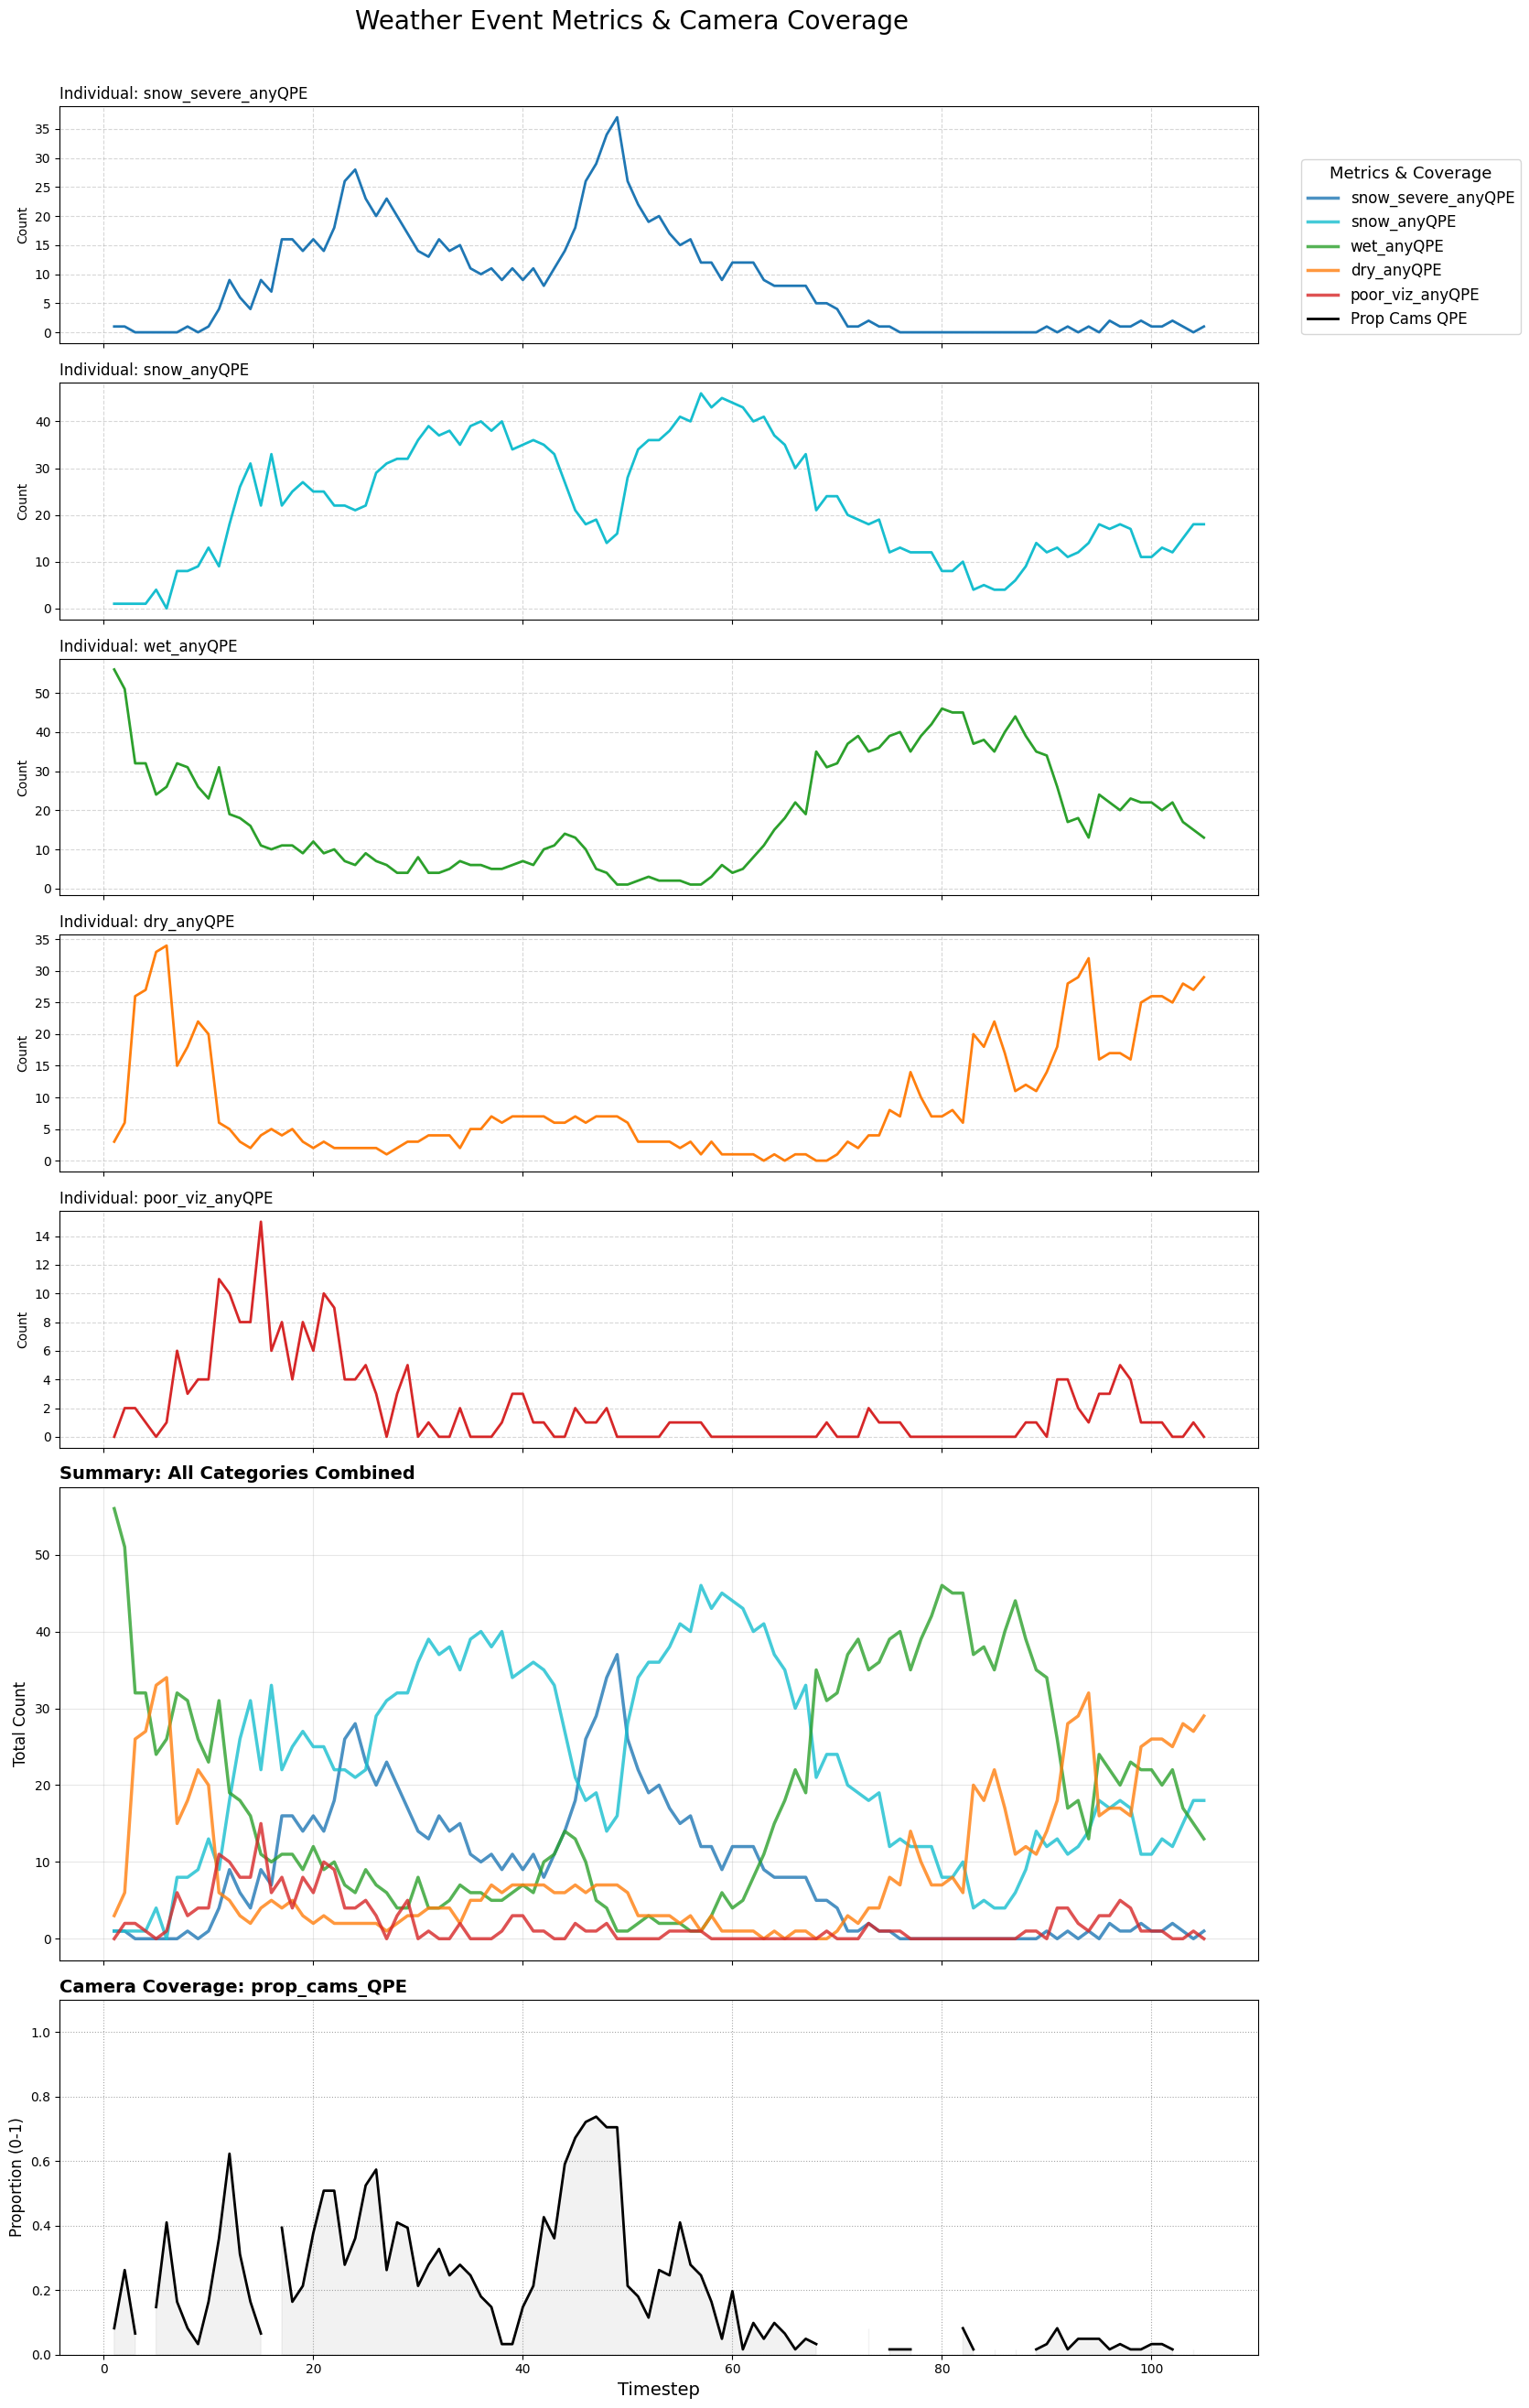

In [25]:
plot_7()

In [15]:
de[0:30]

,id_event,id_ep,id_type,id_loc,id_wfo,datetime,snow_severe_anyQPE,snow_anyQPE,wet_anyQPE,dry_anyQPE,...,poor_viz_wQPE,totalcams_wQPE,snow_severe_perc_wQPE,snow_perc_wQPE,wet_perc_wQPE,dry_perc_wQPE,poor_viz_perc_wQPE,timestep_wQPE,prop_cams_QPE,timestep
14148,1158057,188432,Lake-Effect Snow,ONONDAGA,BGM,20240229_0100,1,1,56,3,...,0.0,5.0,0.0000,0.0000,1.0000,0.0000,0.0000,9919.0,0.081967,1
14153,1158057,188432,Lake-Effect Snow,ONONDAGA,BGM,20240229_0115,1,1,51,6,...,0.0,16.0,0.0625,0.0000,0.9375,0.0000,0.0000,9921.0,0.262295,2
14154,1158057,188432,Lake-Effect Snow,ONONDAGA,BGM,20240229_0130,0,1,32,26,...,0.0,4.0,0.0000,0.0000,0.7500,0.2500,0.0000,9925.0,0.065574,3
14158,1158057,188432,Lake-Effect Snow,ONONDAGA,BGM,20240229_0145,0,1,32,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
14161,1158057,188432,Lake-Effect Snow,ONONDAGA,BGM,20240229_0200,0,4,24,33,...,0.0,9.0,0.0000,0.2222,0.4444,0.3333,0.0000,9927.0,0.147541,5
14165,1158057,188432,Lake-Effect Snow,ONONDAGA,BGM,20240229_0215,0,0,26,34,...,1.0,25.0,0.0000,0.0000,0.3600,0.6000,0.0400,9930.0,0.409836,6
14171,1158057,188432,Lake-Effect Snow,ONONDAGA,BGM,20240229_0230,0,8,32,15,...,2.0,10.0,0.0000,0.0000,0.5000,0.3000,0.2000,9931.0,0.163934,7
14172,1158057,188432,Lake-Effect Snow,ONONDAGA,BGM,20240229_0245,1,8,31,18,...,1.0,5.0,0.0000,0.0000,0.6000,0.2000,0.2000,9934.0,0.081967,8
14178,1158057,188432,Lake-Effect Snow,ONONDAGA,BGM,20240229_0300,0,9,26,22,...,0.0,2.0,0.0000,0.0000,1.0000,0.0000,0.0000,9935.0,0.032787,9
14180,1158057,188432,Lake-Effect Snow,ONONDAGA,BGM,20240229_0315,1,13,23,20,...,1.0,10.0,0.1000,0.4000,0.4000,0.0000,0.1000,9937.0,0.163934,10


number of cams:
[111]
['Lake-Effect Snow']


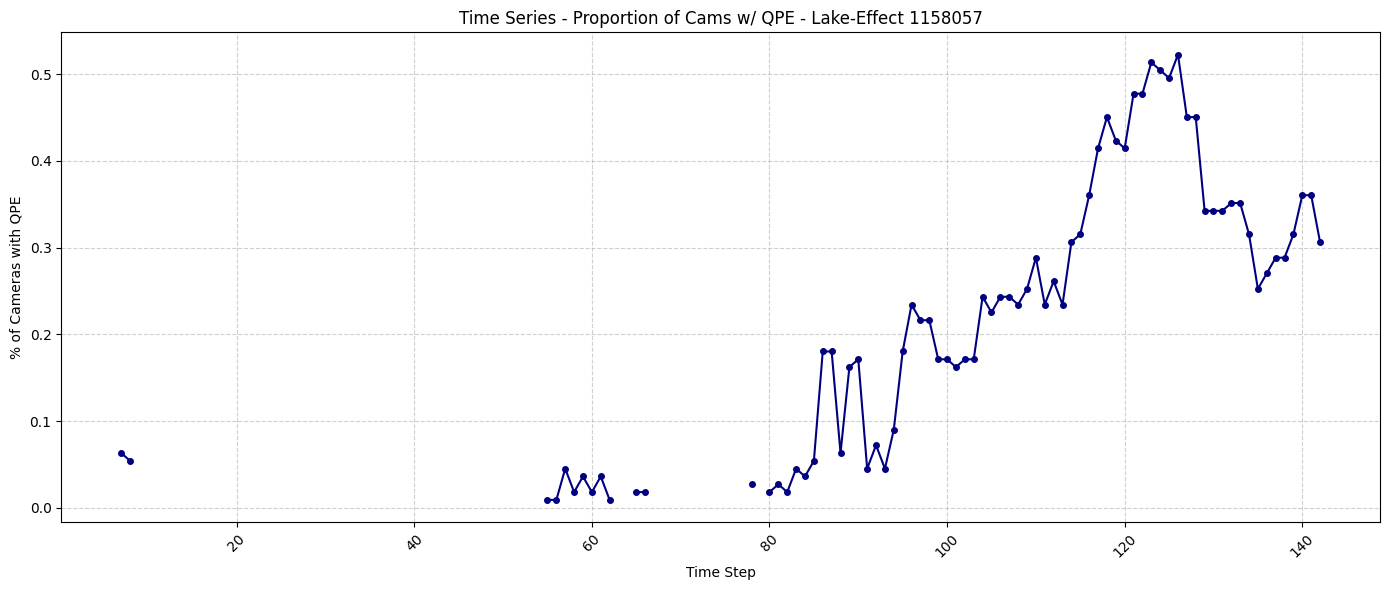

In [26]:
de = data[data["id_event"] == 1225430] #data.head(13)
de = de[~de["id_type"].isin(["buffer_before","buffer_after"])]
de = de.sort_values("datetime")

de['timestep'] = range(1, len(de)+1)

print("number of cams:")
print(np.unique(de["totalcams_anyQPE"]))

print(np.unique(de["id_type"]))

de.head(3)

make_qpe_timeseries(dfforplot = de, plotsubtitle = "Lake-Effect 1225430")

# maybe the QPE DOES explain it?? See viz plots from other  nb

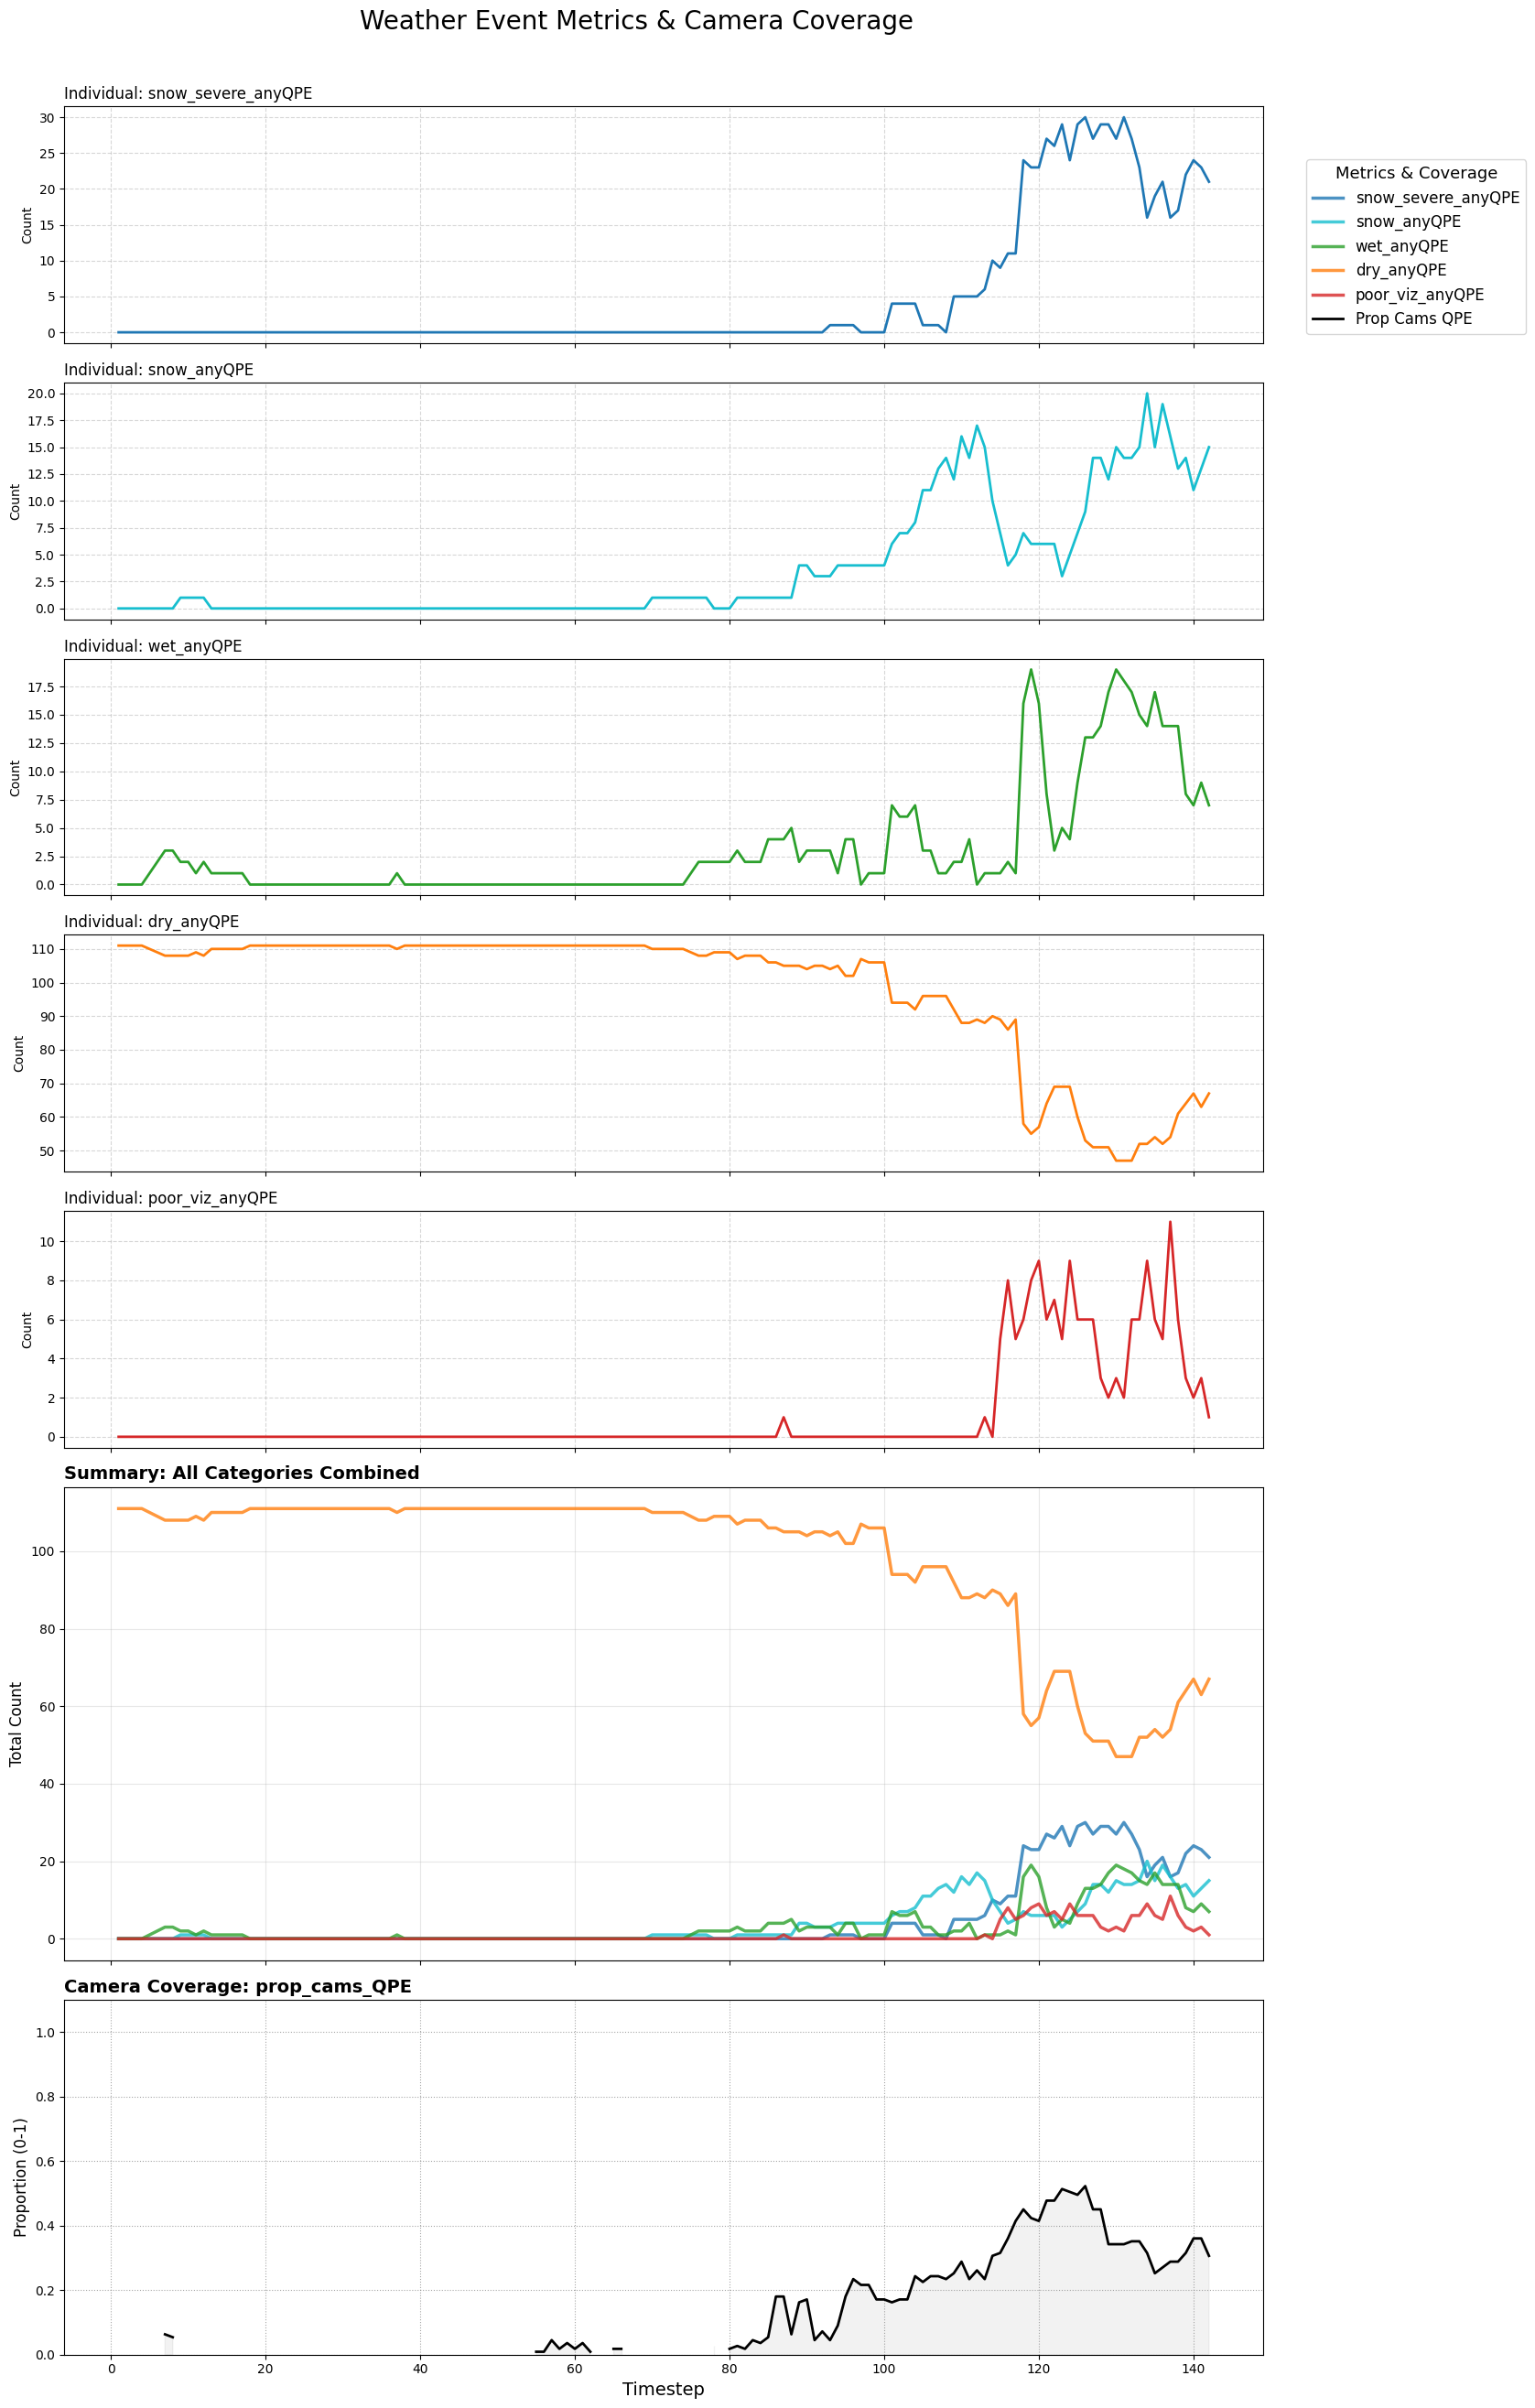

In [27]:
plot_7()

number of cams:
[121]
['Winter Weather']


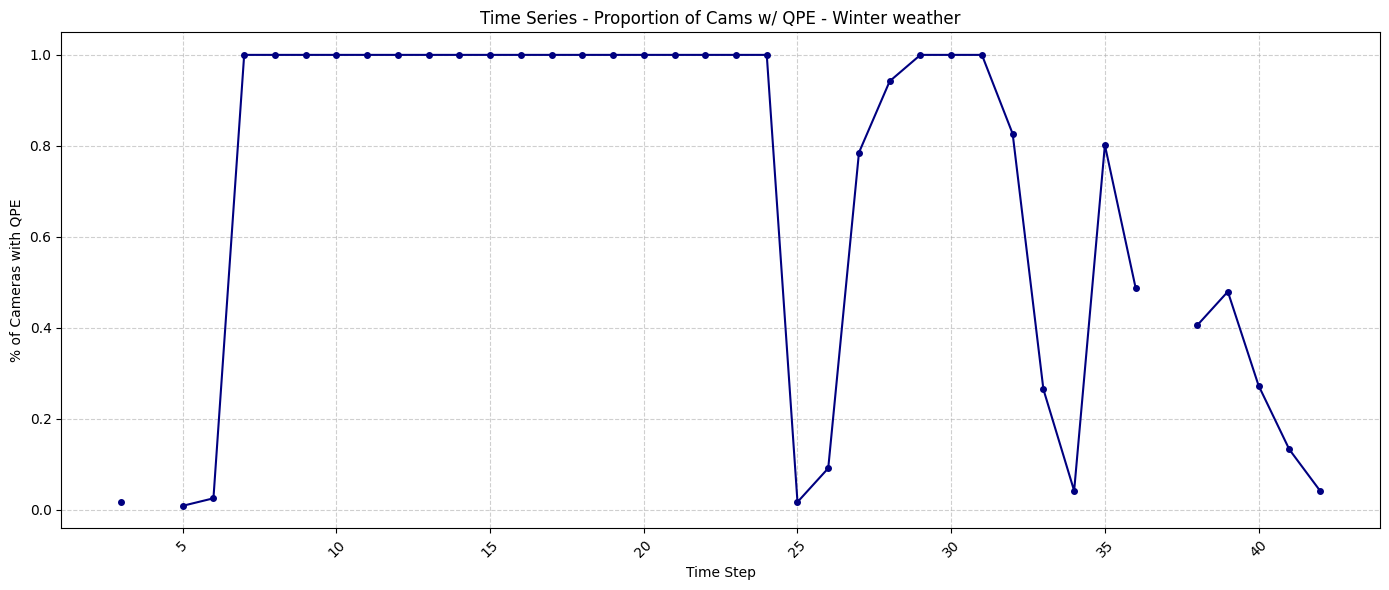

In [30]:


de = data[data["id_event"] == 1152731] #data.head(13)
de = de[~de["id_type"].isin(["buffer_before","buffer_after"])]
de = de.sort_values("datetime")

de['timestep'] = range(1, len(de)+1)

print("number of cams:")
print(np.unique(de["totalcams_anyQPE"]))

print(np.unique(de["id_type"]))

de.head(3)

make_qpe_timeseries(dfforplot = de, plotsubtitle = "Winter weather")

# maybe the QPE DOES explain it?? See viz plots from other  nb

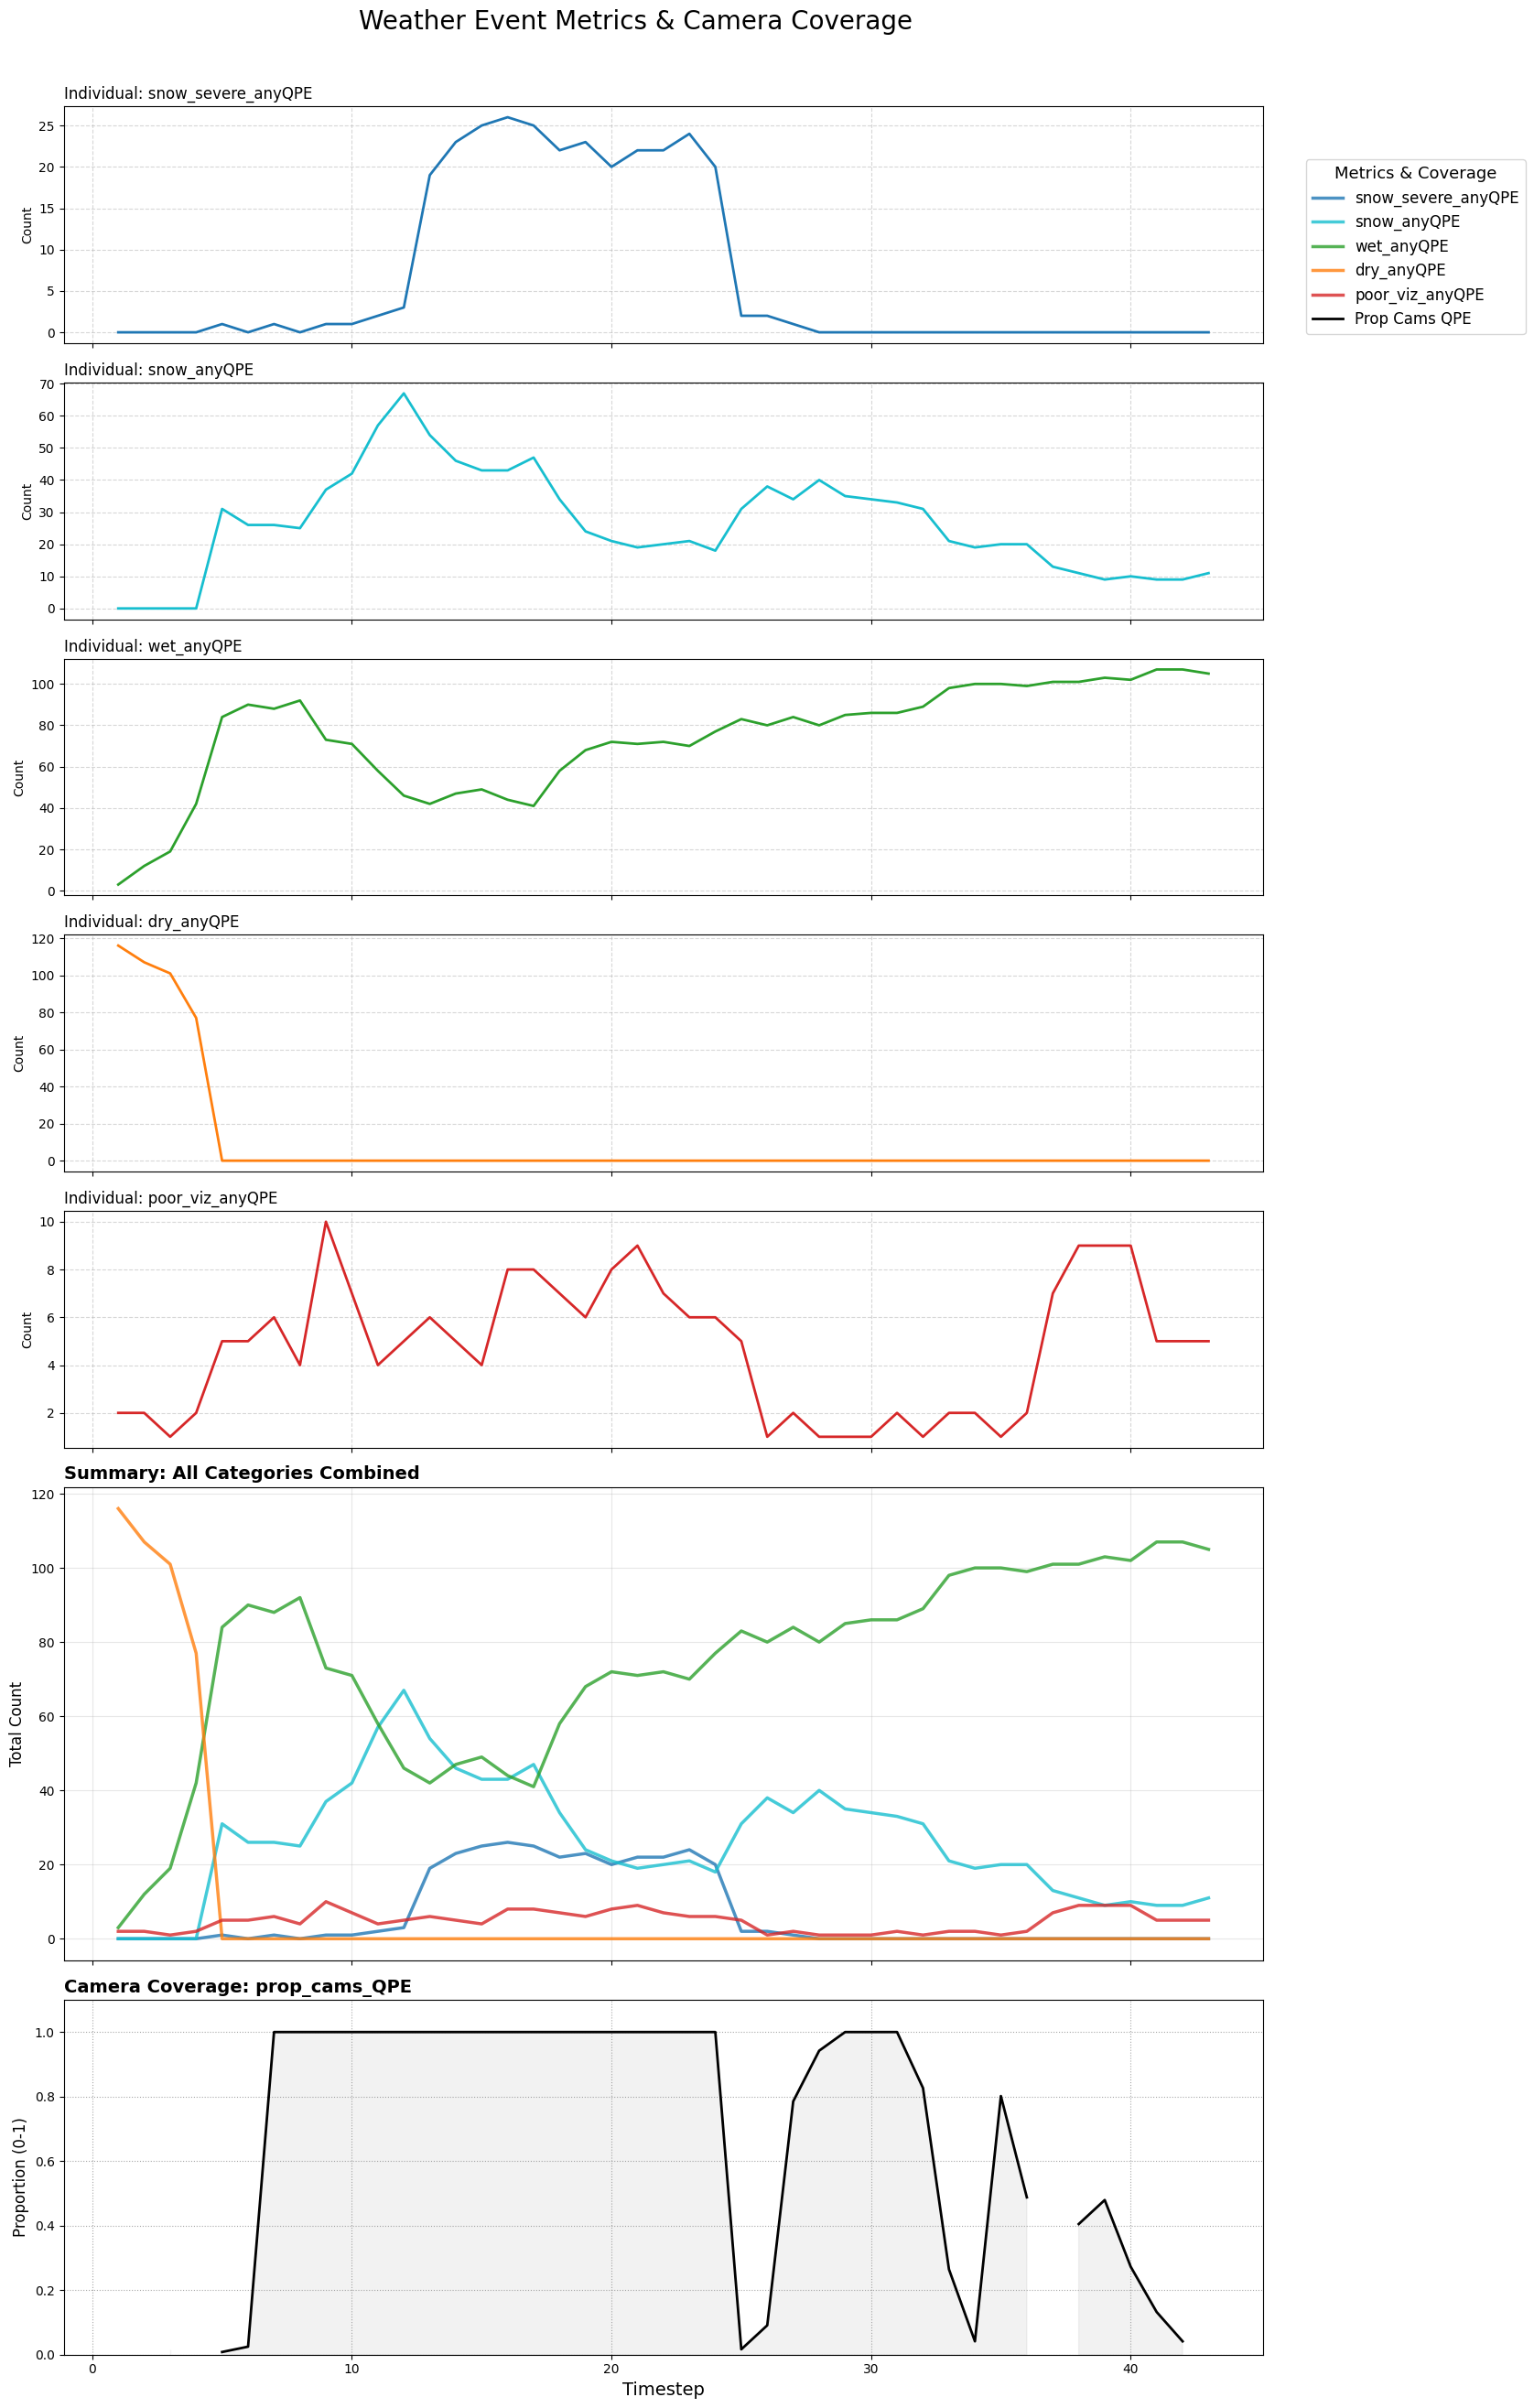

In [33]:
plot_7()

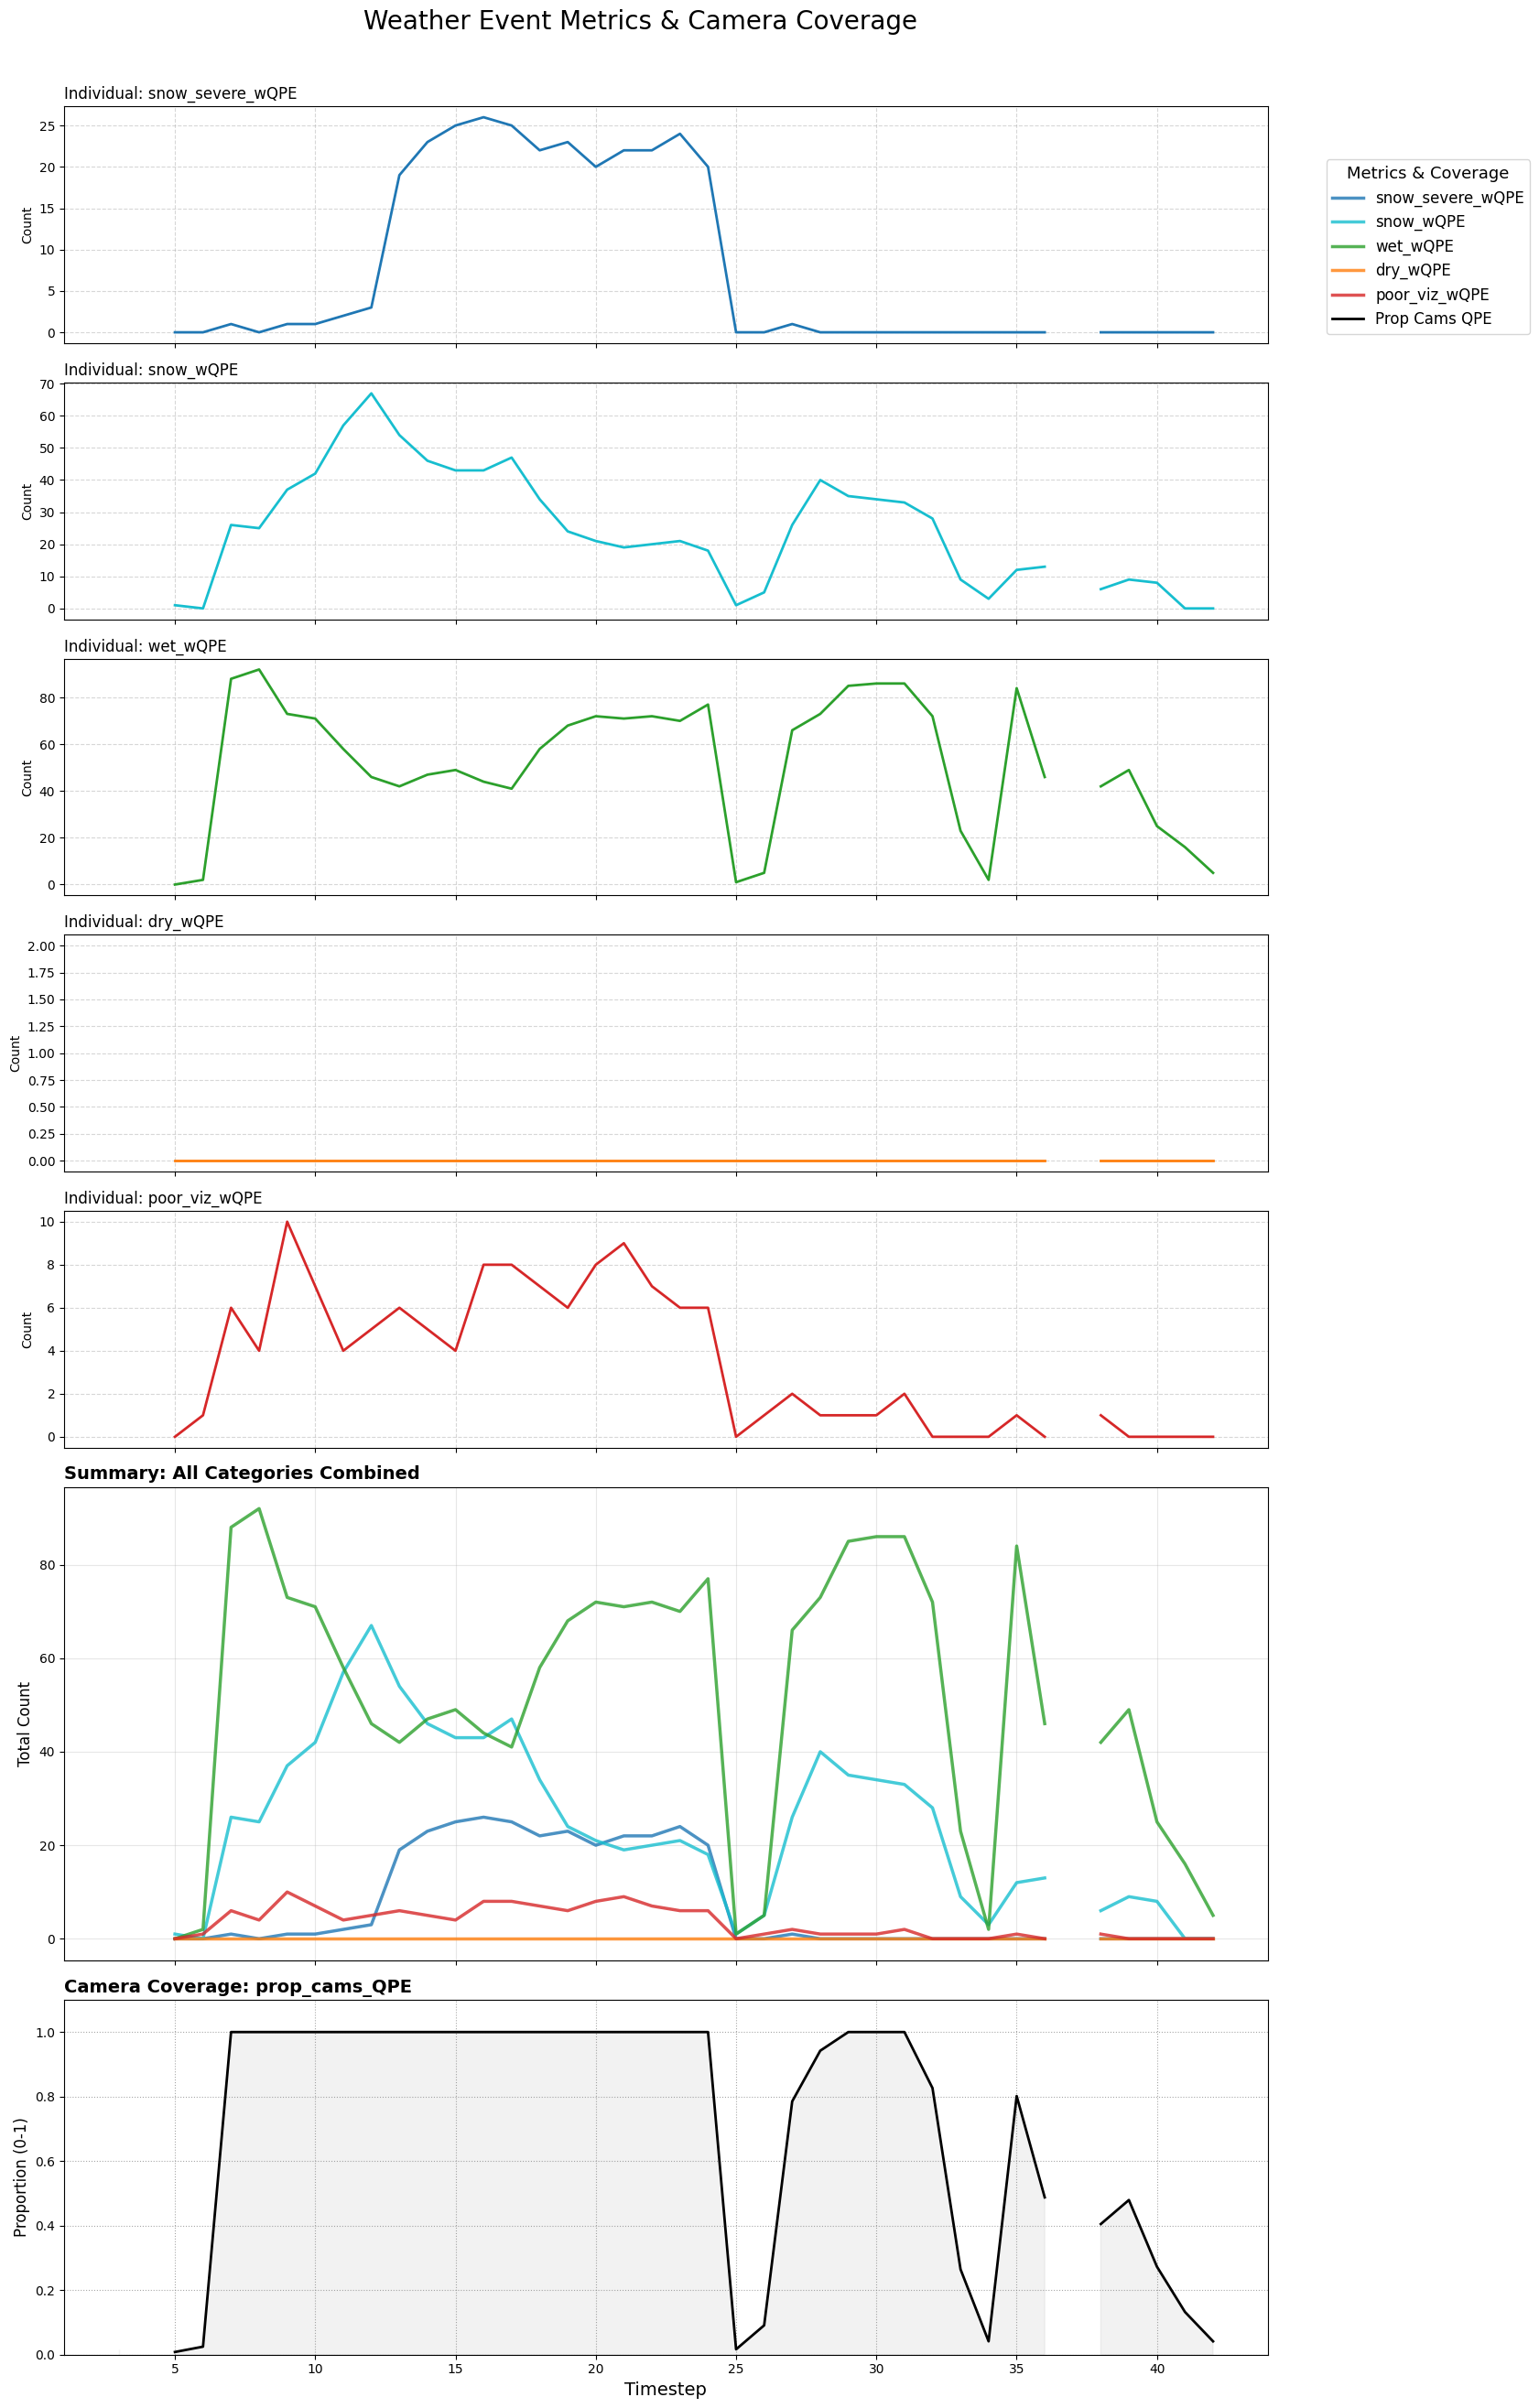

In [34]:
plot_7_wqpe()

In [8]:
# Investigate this one to dig into QPE data

de.head(40)

# 1152731,187707,Winter Weather,NORTHERN QUEENS,OKX,20240217_1130

# 1152731,187707,Winter Weather,NORTHERN QUEENS,OKX,20240217_1430

,id_event,id_ep,id_type,id_loc,id_wfo,datetime,snow_severe_anyQPE,snow_anyQPE,wet_anyQPE,dry_anyQPE,...,poor_viz_wQPE,totalcams_wQPE,snow_severe_perc_wQPE,snow_perc_wQPE,wet_perc_wQPE,dry_perc_wQPE,poor_viz_perc_wQPE,timestep_wQPE,prop_cams_QPE,timestep
13531,1152731,187707,Winter Weather,NORTHERN QUEENS,OKX,20240217_0530,0,0,3,116,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1
13541,1152731,187707,Winter Weather,NORTHERN QUEENS,OKX,20240217_0545,0,0,12,107,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2
13550,1152731,187707,Winter Weather,NORTHERN QUEENS,OKX,20240217_0600,0,0,19,101,...,0.0,2.0,0.0000,0.0000,0.0000,1.0,0.0000,9404.0,0.016529,3
13561,1152731,187707,Winter Weather,NORTHERN QUEENS,OKX,20240217_0615,0,0,42,77,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4
13568,1152731,187707,Winter Weather,NORTHERN QUEENS,OKX,20240217_0630,1,31,84,0,...,0.0,1.0,0.0000,1.0000,0.0000,0.0,0.0000,9419.0,0.008264,5
13583,1152731,187707,Winter Weather,NORTHERN QUEENS,OKX,20240217_0645,0,26,90,0,...,1.0,3.0,0.0000,0.0000,0.6667,0.0,0.3333,9427.0,0.024793,6
13590,1152731,187707,Winter Weather,NORTHERN QUEENS,OKX,20240217_0700,1,26,88,0,...,6.0,121.0,0.0083,0.2149,0.7273,0.0,0.0496,9441.0,1.000000,7
13606,1152731,187707,Winter Weather,NORTHERN QUEENS,OKX,20240217_0715,0,25,92,0,...,4.0,121.0,0.0000,0.2066,0.7603,0.0,0.0331,9451.0,1.000000,8
13617,1152731,187707,Winter Weather,NORTHERN QUEENS,OKX,20240217_0730,1,37,73,0,...,10.0,121.0,0.0083,0.3058,0.6033,0.0,0.0826,9463.0,1.000000,9
13624,1152731,187707,Winter Weather,NORTHERN QUEENS,OKX,20240217_0745,1,42,71,0,...,7.0,121.0,0.0083,0.3471,0.5868,0.0,0.0579,9468.0,1.000000,10


# [old work] Histogram by event type

In [85]:
# DEFINE PLOT FUNCTION
# import matplotlib.pyplot as plt



catslist = ["snow_severe", "snow", "wet", "dry", "poor_viz"]

def makeplot(df,evtype):

    # df = group_stormphase_sumcats

    # 1. aggregate the proportions for an event type across multiple rows (multiple events)

    prop_cols = [] 

    for col in catslist:
        prop_name = col + '_prop'
        df[prop_name] = df[col] / df['totalcams']
        prop_cols.append(prop_name)
    

    # 2. Group by id_type and get the average proportions
    # This creates a table where rows = id_type and columns = average cat proportions
    summary_df = df.groupby('id_type', sort=False)[prop_cols].mean()

    # Rename columns back to original names for a cleaner legend
    summary_df.columns = catslist


    # 3. Plotting
    ax = summary_df.plot(kind='bar', 
                        stacked=False, 
                        figsize=(12, 7), 
                        colormap='tab10', 
                        edgecolor='white')

    # 4. Formatting
    # The main centered "Super" title
    plt.suptitle(f"{evtype}", fontsize=18, fontweight='bold')

    # The secondary subtitle (your original title)
    plt.title(f"Proportion of Model Predicted Classes - Before, During, and After", fontsize=14)
    
    plt.ylabel("Average Proportion (0.0 - 1.0)")
    plt.xlabel("Stage of Event")
    plt.legend(title="Model Prediction", bbox_to_anchor=(.88, 1), loc='upper left')
    plt.xticks(rotation=45)

    # Optional: Add a grid for the y-axis to help read proportions
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [112]:
g1.head(2)

,id_type,id_event
0,Blizzard,"[996910, 996866, 996866, 996910, 996866, 99691..."
1,Heavy Rain,"[1193087, 1193087, 1193087, 1193087, 1193087, ..."


In [113]:
subsetevents.head(3)

,index,id_event,id_ep,id_type,id_loc,id_wfo,datetime,snow_severe,snow,wet,dry,poor_viz,totalcams,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
0,27350,1152943,999,buffer_before,STEUBEN,BGM,20240106_1615,0,0,0,1,0,1,0.0,0.0,0.0000,1.0000,0.0,1262
1,27333,1152943,999,buffer_before,STEUBEN,BGM,20240106_1630,0,0,1,8,0,9,0.0,0.0,0.1111,0.8889,0.0,1263
2,27346,1152943,999,buffer_before,STEUBEN,BGM,20240106_1645,0,0,5,3,0,8,0.0,0.0,0.6250,0.3750,0.0,1264


,id_type,id_event
0,Blizzard,"[996910, 996866, 996866, 996910, 996866, 99691..."
1,Heavy Rain,"[1193087, 1193087, 1193087, 1193087, 1193087, ..."
2,Heavy Snow,"[1151589, 1151587, 1151590, 1151589, 1151587, ..."
3,Lake-Effect Snow,"[1159185, 1159185, 1159185, 1159185, 1159185, ..."
4,Winter Storm,"[1146894, 1146894, 1146894, 1146894, 1146894, ..."
5,Winter Weather,"[1152943, 1152943, 1152943, 1152943, 1151677, ..."


,id_type,snow_severe,snow,wet,dry,poor_viz,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,totalcams
0,buffer_before,346,88,186,0,46,12.1467,5.2399,2.4225,0.0000,1.1909,666
1,Blizzard,45338,3204,749,25,2294,1026.6852,131.2700,10.0314,5.7725,44.2316,51610
2,buffer_after,507,47,2,0,3,18.5092,2.9622,0.2500,0.0000,0.2786,559


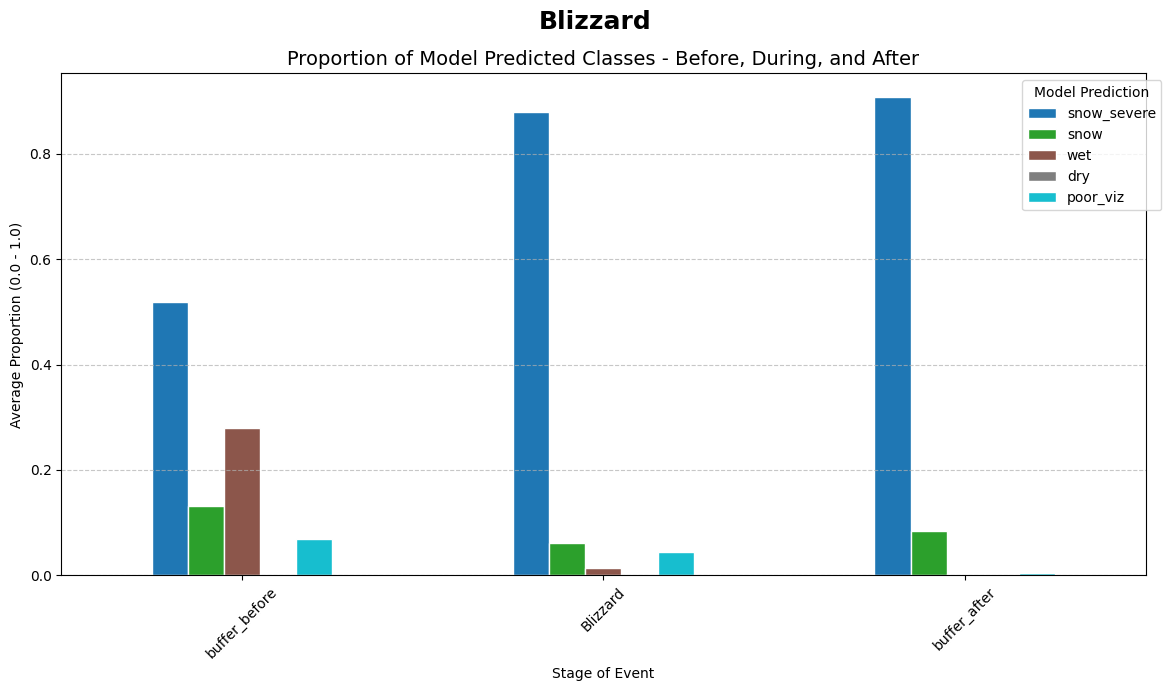

,id_type,snow_severe,snow,wet,dry,poor_viz,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,totalcams
0,buffer_before,0,0,98,98,1,0.0,0.0,3.9796,6.0000,0.0204,197
1,Heavy Rain,0,0,102,52,4,0.0,0.0,4.6666,8.0716,0.2619,158
2,buffer_after,0,0,1068,34,8,0.0,0.0,7.7180,3.2143,0.0677,1110


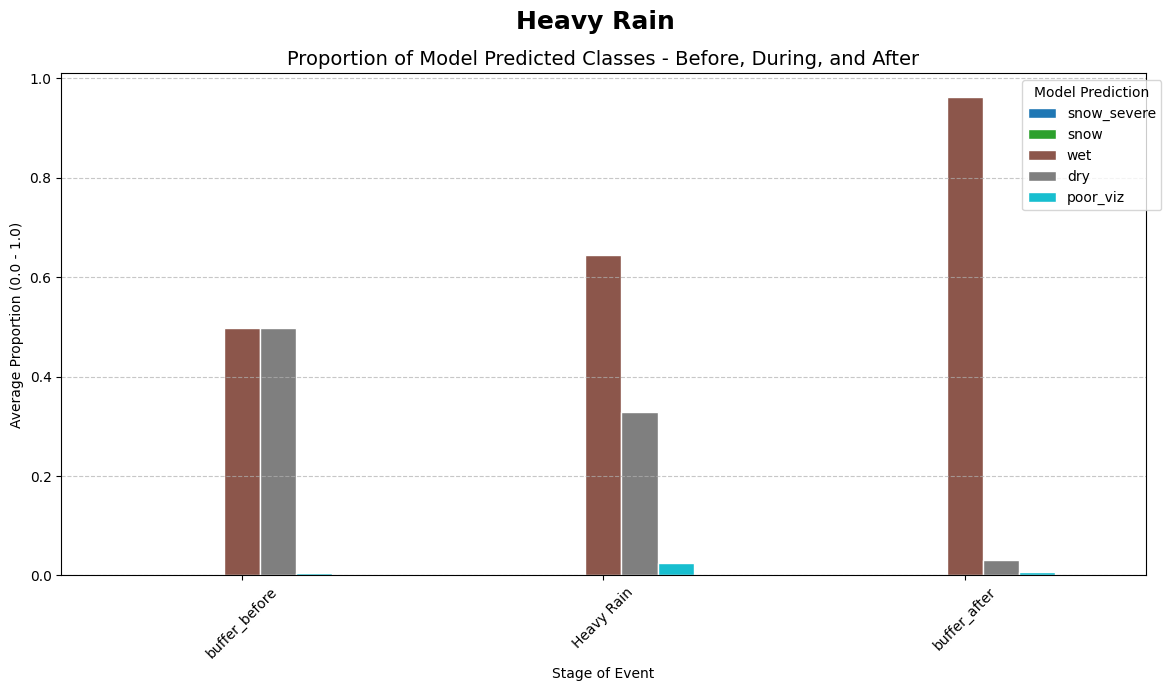

,id_type,snow_severe,snow,wet,dry,poor_viz,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,totalcams
0,buffer_before,10,131,790,371,51,0.8076,13.4638,60.1301,46.3606,8.2378,1353
1,Heavy Snow,9288,19875,9698,1375,2306,809.2670,1763.9820,994.6432,114.3993,254.7067,42542
2,buffer_after,58,128,159,1,16,5.2513,22.7172,32.2311,0.2500,3.5504,362


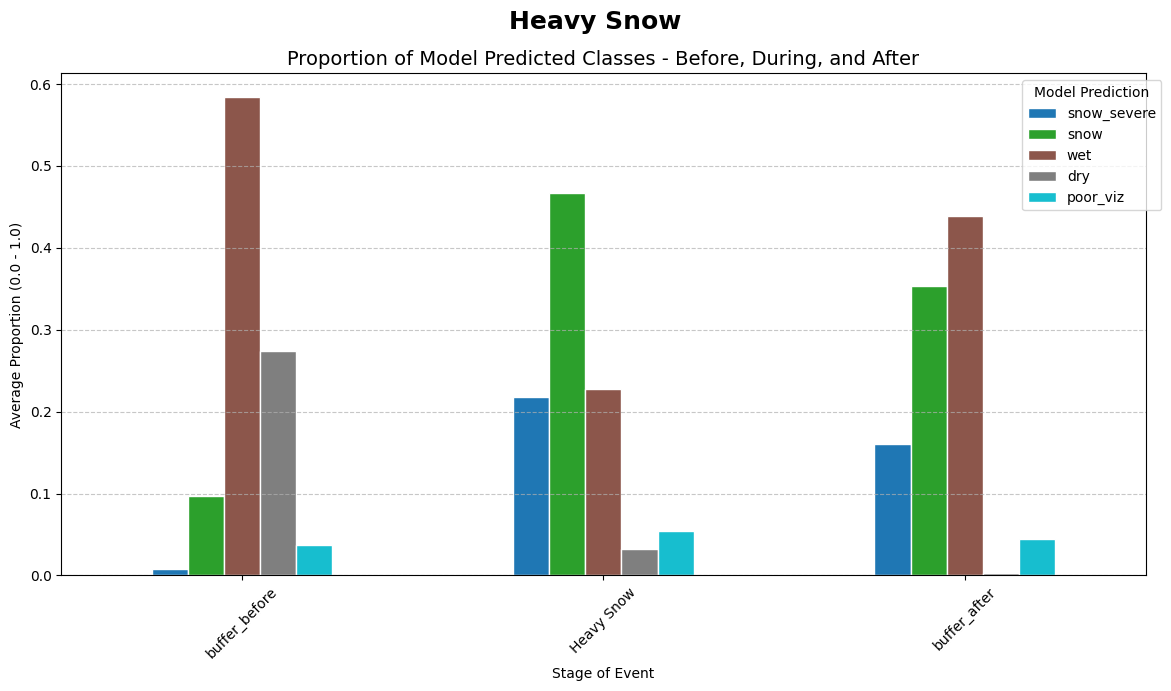

,id_type,snow_severe,snow,wet,dry,poor_viz,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,totalcams
0,buffer_before,413,1159,691,235,62,23.8361,55.4217,55.7653,25.7451,3.2316,2560
1,Lake-Effect Snow,18690,27359,9494,3194,2525,2055.1079,2974.9285,1132.2101,570.8717,276.8860,61262
2,buffer_after,218,849,131,32,13,16.6440,46.7236,14.2579,8.0072,3.3674,1243


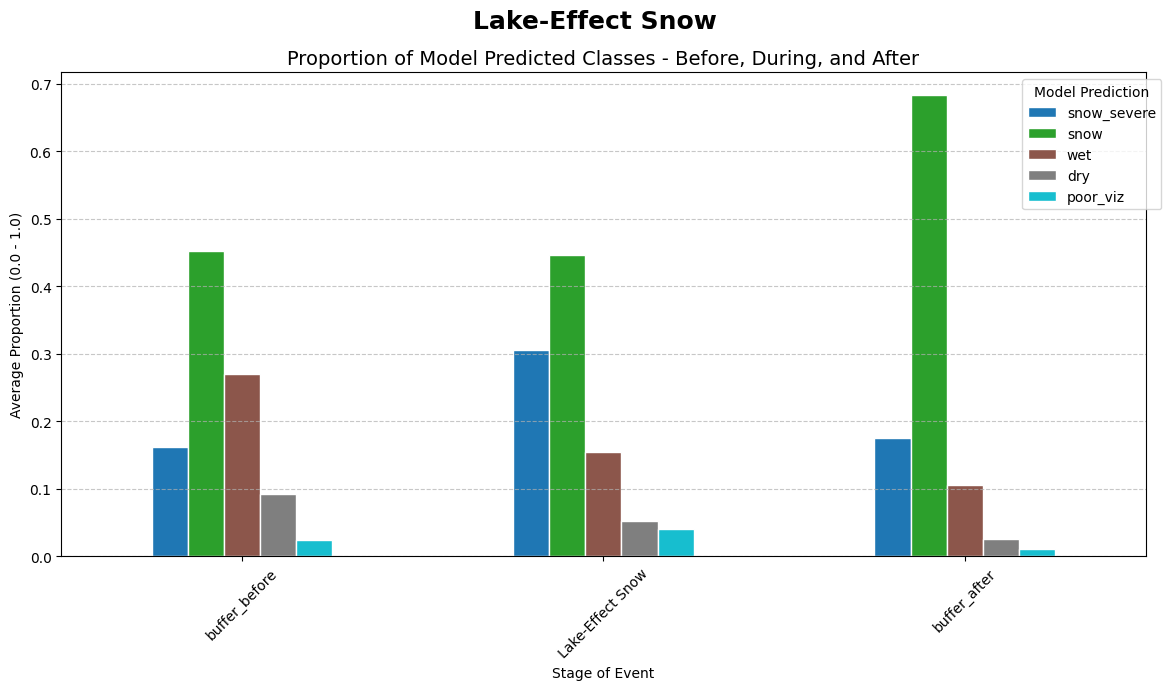

,id_type,snow_severe,snow,wet,dry,poor_viz,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,totalcams
0,buffer_before,35,308,338,32,19,3.5884,14.7909,16.6726,12.1610,2.7869,732
1,Winter Storm,8994,12328,6213,635,1585,1232.9094,1480.3975,1030.4430,151.6752,326.5706,29755
2,buffer_after,103,314,83,2,10,19.3122,20.0242,21.9969,0.5000,5.1666,512


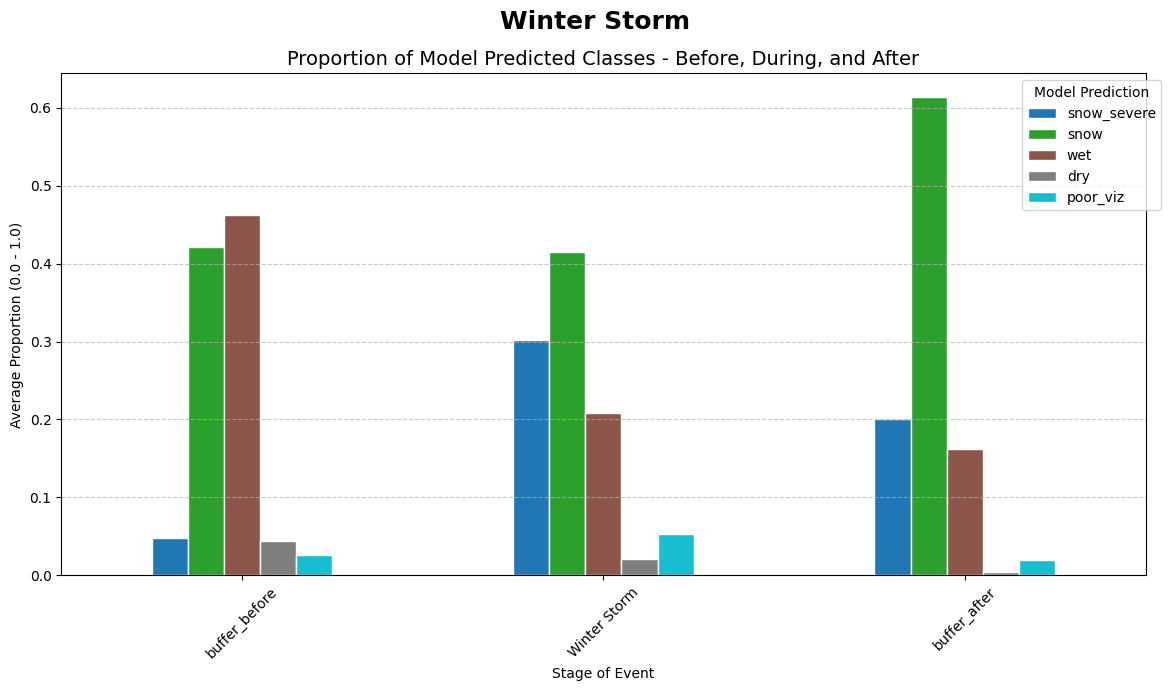

,id_type,snow_severe,snow,wet,dry,poor_viz,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,totalcams
0,buffer_before,81,270,3750,1534,187,11.2064,26.2135,165.6049,89.7030,25.2719,5822
1,Winter Weather,17916,49579,72965,3932,6794,1330.9382,3457.3912,4106.6132,340.4390,645.6020,151186
2,buffer_after,279,691,1126,50,96,28.2733,72.8492,133.3294,8.5348,15.0132,2242


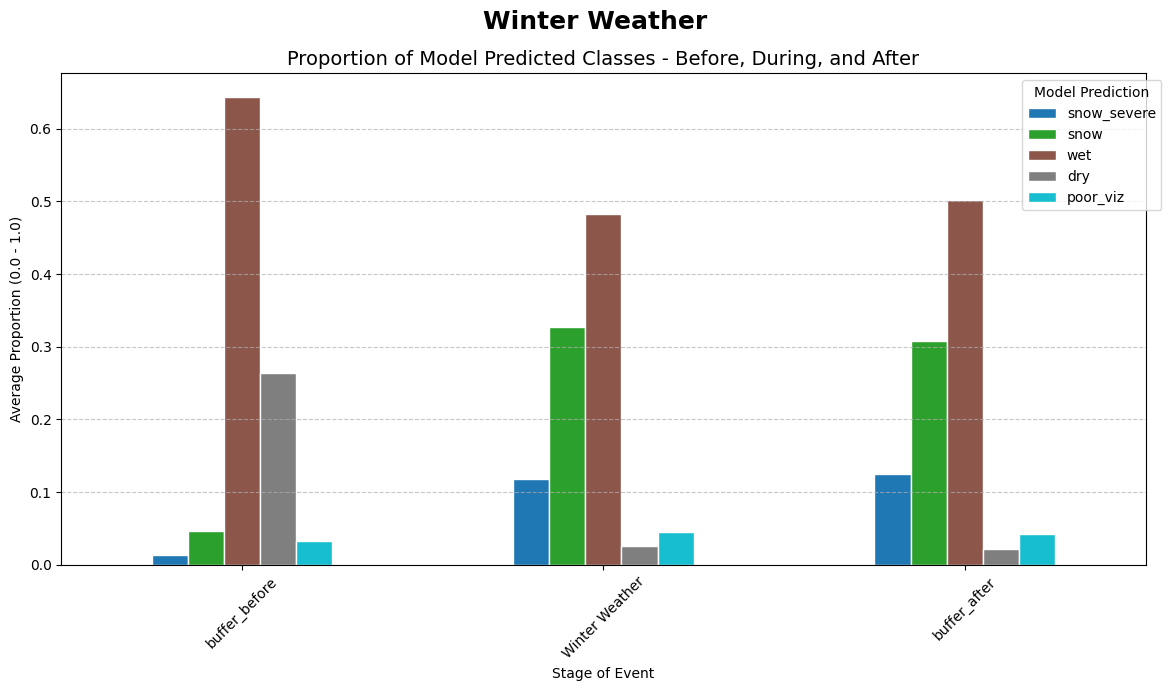

In [115]:
stats_wpreds_allinfo

# grab event ids associated with each main weather type. Ignore buffer_before and buffer_after
weatherevents = stats_wpreds_allinfo[((stats_wpreds_allinfo["id_type"]!="buffer_before")&(stats_wpreds_allinfo["id_type"]!="buffer_after"))]

g1 = weatherevents.groupby('id_type')['id_event'].agg(list).reset_index()
display(g1)


# for each even type (blizzard), subset main df to just those id_event (which will also tie in buffer_before and buffer_after),  and then aggregate stats for them

for type in g1["id_type"]:
    eventlist = g1[g1["id_type"]==type]["id_event"].item()
    # grab those events from the main df
    subsetevents = stats_wpreds_allinfo[stats_wpreds_allinfo["id_event"].isin(eventlist)].reset_index()
    #  group by before buffer, during event, and after buffer
    group_stormphase_sumcats = subsetevents[["id_type","snow_severe", "snow", "wet", "dry", "poor_viz",'snow_severe_perc',
       'snow_perc', 'wet_perc', 'dry_perc', 'poor_viz_perc',"totalcams"]].groupby(["id_type"]).sum().reset_index()

    order_df = ["buffer_before",type, "buffer_after"]
    
    group_stormphase_sumcats = group_stormphase_sumcats.set_index("id_type").loc[order_df].reset_index()

    display(group_stormphase_sumcats)

    makeplot(df = group_stormphase_sumcats,evtype = type)

    # Could run longer buffer (before/after) to get a better picture / more data there (e.g. many events themselves run a day or more, but for buffer I only pulled the 60 min before / after. Could also cosnider running the frequency that I ran the cases at (e.g. if 5 min rather thand 15)



In [116]:
stats_wpreds_allinfo.head(3)

,id_event,id_ep,id_type,id_loc,id_wfo,datetime,snow_severe,snow,wet,dry,poor_viz,totalcams,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
26310,996910,999,buffer_before,NORTHWEST SUFFOLK,OKX,20220129_1100,52,1,0,0,3,56,0.9286,0.0179,0.0,0.0,0.0536,1
26311,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_1100,50,0,0,0,9,59,0.8475,0.0000,0.0,0.0,0.1525,2
26322,996910,999,buffer_before,NORTHWEST SUFFOLK,OKX,20220129_1115,53,1,0,0,2,56,0.9464,0.0179,0.0,0.0,0.0357,3


In [75]:
stats_wpreds_allinfo.columns

Index(['id_event', 'id_ep', 'id_type', 'id_loc', 'id_wfo', 'datetime',
       'snow_severe', 'snow', 'wet', 'dry', 'poor_viz', 'totalcams',
       'snow_severe_perc', 'snow_perc', 'wet_perc', 'dry_perc',
       'poor_viz_perc', 'timestep'],
      dtype='object')

# SCRATCH WORK W/ DUPS

In [ ]:
data_wqpe = data_wqpe.drop(columns = ["index"])


In [ ]:
data_wqpe = stats_wpreds_allinfo

data_wqpe = data_wqpe.drop(columns = ["index", "model_counts","cat_percents", "cat_counts"]) # cols that are dict and list b/c they're weird for pd operations and we've already added the data by cols that we need
print(len(data_wqpe))

In [ ]:
data_wqpe = data_wqpe.drop(columns = ['timestep'])

In [ ]:
print(len(data_wqpe))

39290


In [ ]:
data_anyqpe = stats_wpreds_allinfo
data_anyqpe = data_anyqpe.drop(columns = ["index", "model_counts","cat_percents", "cat_counts"])

print(len(data_anyqpe))

62481


In [ ]:
data_anyqpe = data_anyqpe.drop(columns = ['timestep'])

In [ ]:
data_anyqpe.columns

Index(['index', 'id_event', 'id_ep', 'id_type', 'id_loc', 'id_wfo', 'datetime',
       'model_counts', 'cat_counts', 'snow_severe', 'snow', 'wet', 'dry',
       'poor_viz', 'totalcams', 'cat_percents', 'snow_severe_perc',
       'snow_perc', 'wet_perc', 'dry_perc', 'poor_viz_perc', 'timestep'],
      dtype='object')

In [ ]:
data_anyqpe.head(2)

,id_event,id_ep,id_type,id_loc,id_wfo,datetime,cat_counts,snow_severe,snow,wet,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
62476,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_1100,"[50, 0, 0, 0, 9]",50,0,0,0,9,59,"[0.8475, 0.0, 0.0, 0.0, 0.1525]",0.8475,0.0000,0.0,0.0,0.1525,1
62475,996910,999,buffer_before,NORTHWEST SUFFOLK,OKX,20220129_1100,"[52, 1, 0, 0, 3]",52,1,0,0,3,56,"[0.9286, 0.0179, 0.0, 0.0, 0.0536]",0.9286,0.0179,0.0,0.0,0.0536,2


In [ ]:
# check dups
# d1 = data_wqpe[mergeon]
# d2 = d1.unique()

print(len(data_wqpe[mergeon].drop_duplicates()))
print(len(data_anyqpe[mergeon].drop_duplicates()))

30026
44896


In [ ]:
data_wqpe.head(2)

,id_event,id_ep,id_type,id_loc,id_wfo,datetime,snow_severe,snow,wet,dry,poor_viz,totalcams,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
39285,996866,999,buffer_before,SOUTHWEST SUFFOLK,OKX,20220129_1100,50,0,0,0,9,59,0.8475,0.0000,0.0,0.0,0.1525,1
39284,996910,999,buffer_before,NORTHWEST SUFFOLK,OKX,20220129_1100,52,1,0,0,3,56,0.9286,0.0179,0.0,0.0,0.0536,2


In [ ]:
dd1 = data_wqpe.drop_duplicates(ignore_index=True)
dd2 = data_anyqpe.drop_duplicates(ignore_index=True)
print(len(dd1))
print(len(dd2))

30026
44896


In [ ]:
df_cols_toid = data_anyqpe[mergeon]

# Returns a boolean Series
mask = df_cols_toid.duplicated(keep=False)

# Filter the DF to show the duplicates
all_dupes = df_cols_toid[mask]

# keep=False marks all identical rows as True
# all_dupes = df_cols_toid[df_cols_toid.duplicated(keep=False)]

display(all_dupes)

,id_event,id_ep,id_type,id_loc,id_wfo,datetime
7418,1159185,188586,Lake-Effect Snow,OSWEGO,BUF,20240116_2000
24868,1159185,188586,Lake-Effect Snow,OSWEGO,BUF,20240116_2000
7304,1159185,188586,Lake-Effect Snow,OSWEGO,BUF,20240116_2015
24754,1159185,188586,Lake-Effect Snow,OSWEGO,BUF,20240116_2015
7306,1159185,188586,Lake-Effect Snow,OSWEGO,BUF,20240116_2030
...,...,...,...,...,...,...
23369,1238915,199905,Lake-Effect Snow,SOUTHERN ONEIDA,BGM,20250219_0800
18773,1239107,199907,Lake-Effect Snow,ONONDAGA,BGM,20250219_0800
23516,1239107,199907,Lake-Effect Snow,ONONDAGA,BGM,20250219_0800
36223,1239107,199907,Lake-Effect Snow,ONONDAGA,BGM,20250219_0800


In [ ]:
data_anyqpe[((data_anyqpe["id_event"]==1239107)&(data_anyqpe["id_loc"]=="ONONDAGA")&(data_anyqpe["datetime"]=="20250219_0800"))]



,index,id_event,id_ep,id_type,id_loc,id_wfo,datetime,model_counts,cat_counts,snow_severe,...,dry,poor_viz,totalcams,cat_percents,snow_severe_perc,snow_perc,wet_perc,dry_perc,poor_viz_perc,timestep
18773,28773,1239107,199907,Lake-Effect Snow,ONONDAGA,BGM,20250219_0800,"{'dry': 1, 'poor_viz': 4, 'snow': 45, 'snow_se...","[3, 45, 8, 1, 4]",3,...,1,4,61,"[0.0492, 0.7377, 0.1311, 0.0164, 0.0656]",0.0492,0.7377,0.1311,0.0164,0.0656,61729
23516,35554,1239107,199907,Lake-Effect Snow,ONONDAGA,BGM,20250219_0800,"{'dry': 1, 'poor_viz': 4, 'snow': 45, 'snow_se...","[3, 45, 8, 1, 4]",3,...,1,4,61,"[0.0492, 0.7377, 0.1311, 0.0164, 0.0656]",0.0492,0.7377,0.1311,0.0164,0.0656,61730
36223,54188,1239107,199907,Lake-Effect Snow,ONONDAGA,BGM,20250219_0800,"{'dry': 1, 'poor_viz': 4, 'snow': 45, 'snow_se...","[3, 45, 8, 1, 4]",3,...,1,4,61,"[0.0492, 0.7377, 0.1311, 0.0164, 0.0656]",0.0492,0.7377,0.1311,0.0164,0.0656,61731
